In [1]:
%%capture
%pip install -r requirements.txt 

In [2]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'

In [3]:
# =========================
# Standard library imports
# =========================
import os
import sys
import itertools
import re
from pathlib import Path
import warnings
import glob, pickle
from IPython.display import display
warnings.filterwarnings("ignore")

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd

# Plotting
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from timeshap.explainer import local_event, local_feat
from timeshap.plot import plot_event_heatmap, plot_feat_barplot
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ecg_plot

# ML / DL
import tensorflow as tf
from keras.utils import plot_model
from keras.utils import pad_sequences

# Explainability
import timeshap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.utils import check_random_state
from timeshap import explainer as tsx
from timeshap.explainer import calc_global_explanations
from timeshap.explainer import global_report

import sklearn
from sklearn.linear_model import LinearRegression

# SciPy
from scipy import optimize

# =========================
# Project-specific paths
# =========================
physionet_delineation_path = r"...\delineation.py"
physionet_faithfulness_path = r"...\delineation.py"
physionet_bridge_path      = r"...\bridge.py"

sys.path.append(os.path.dirname(physionet_delineation_path))
sys.path.append(os.path.dirname(physionet_faithfulness_path))
sys.path.append(os.path.dirname(physionet_bridge_path))

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))
import physionet_challenge_utility_script_patched_v2 as pc

timeseries_lime_xai_path = r"...\timeseries_lime_xai.py"
sys.path.append(os.path.dirname(timeseries_lime_xai_path))
import timeseries_lime_xai

from timeseries_lime_xai import (
    lime_local, lime_global,
    plot_feature_importance_plotly, plot_event_importance_plotly,
    plot_cell_heatmap_plotly, plot_signal_with_event_overlay_plotly,
    make_model_predict
)

# =========================
# Project-specific imports
# =========================
from delineation import lead_wave_table
from faithfulness import insertion_deletion_auc
from bridge import (
    find_ecg_batch,
    to_batch_L_T,
    make_keras_predict_fn,
    integrated_gradients_keras
)

# =========================
# (Optional) Jupyter autoreload
# =========================
%load_ext autoreload
%autoreload 2


In [4]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)

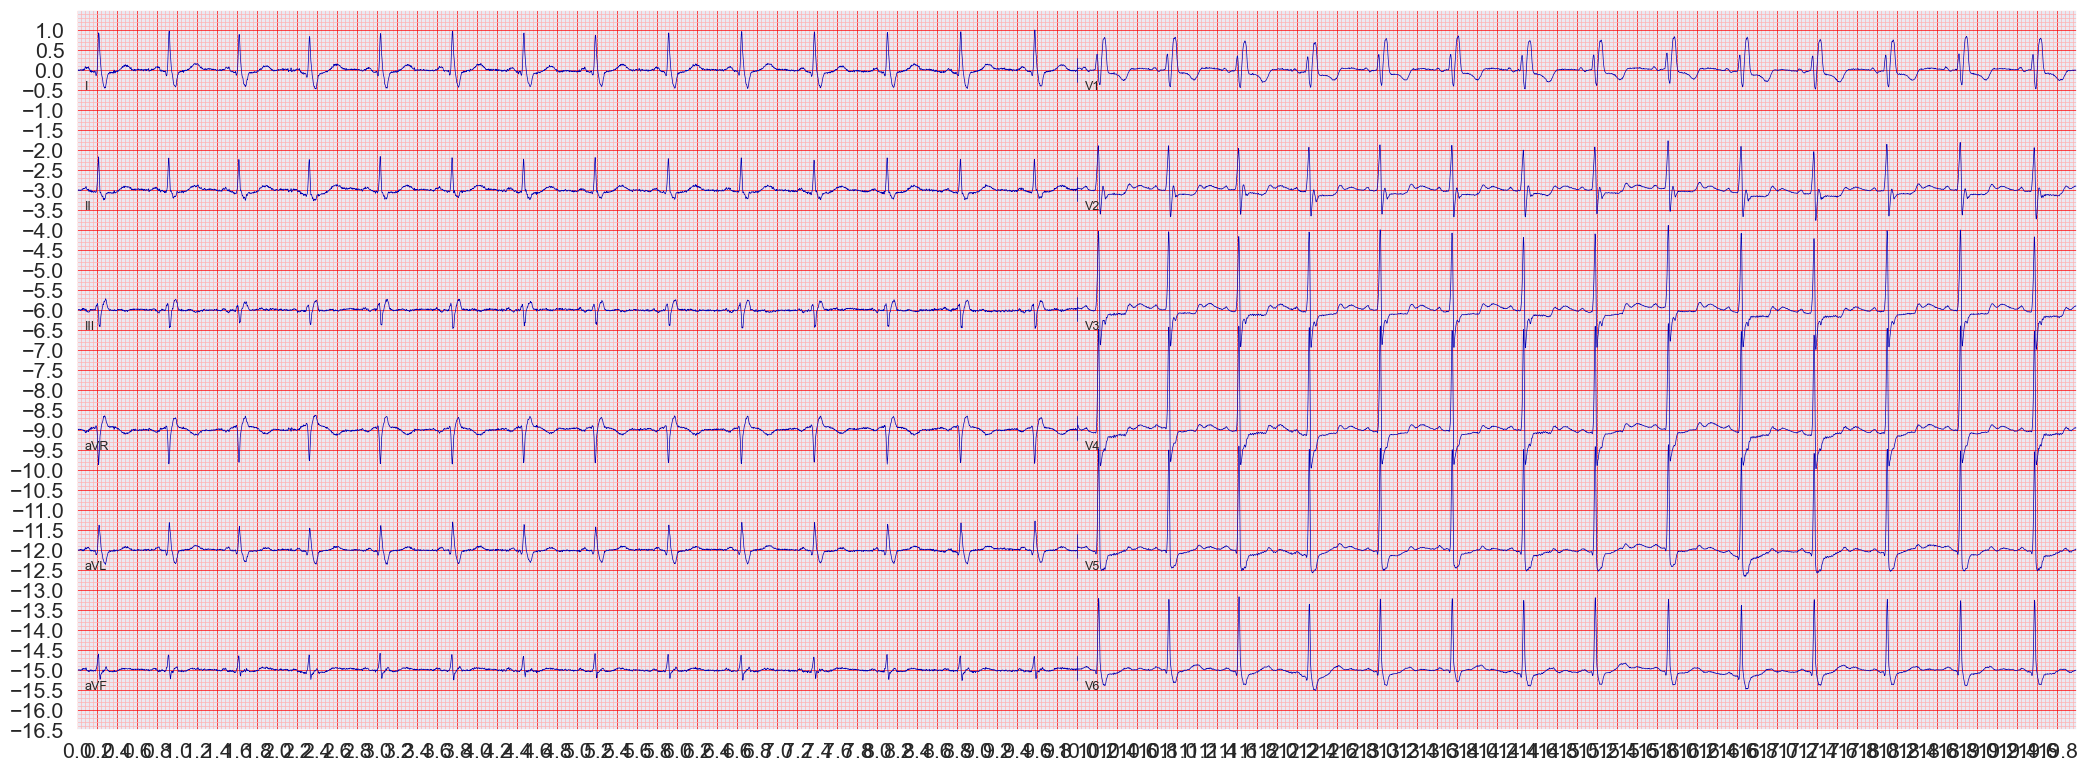

In [155]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [6]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [7]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if you want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if you prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [8]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via your existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [9]:
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

In [10]:
# Load CSV
df = pd.read_csv(CSV_CACHE)

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x = signal_count[:10].index, y = signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()


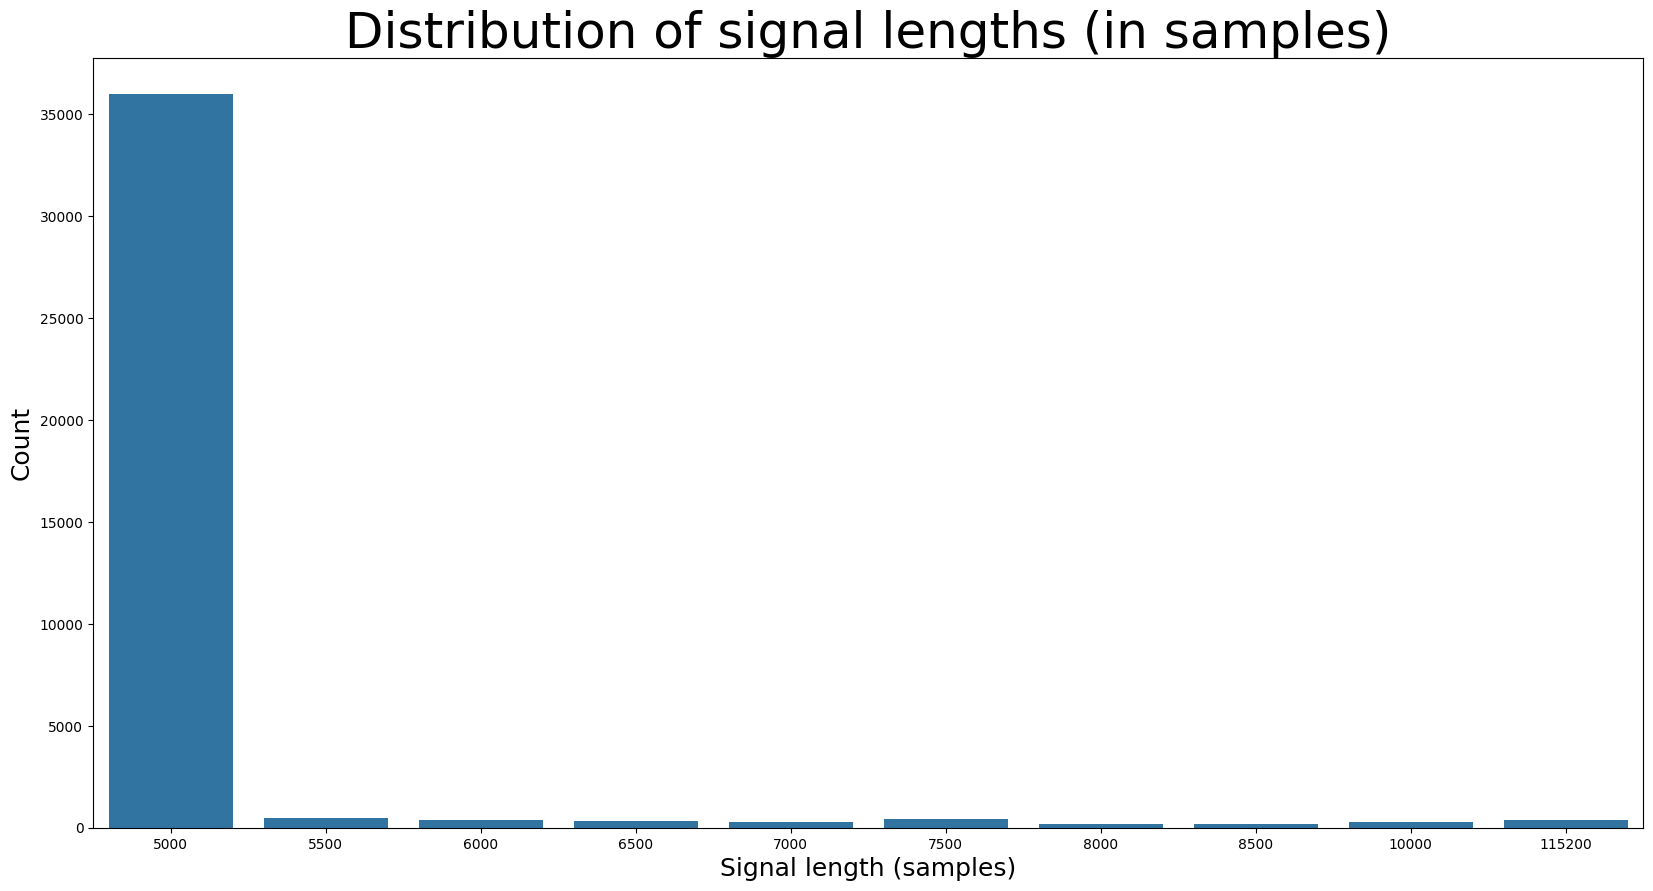

In [11]:
plot_signal_lengths(df, "Distribution of signal lengths (in samples)")

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [12]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [13]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [14]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [15]:
y.shape

(43101, 27)

In [16]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

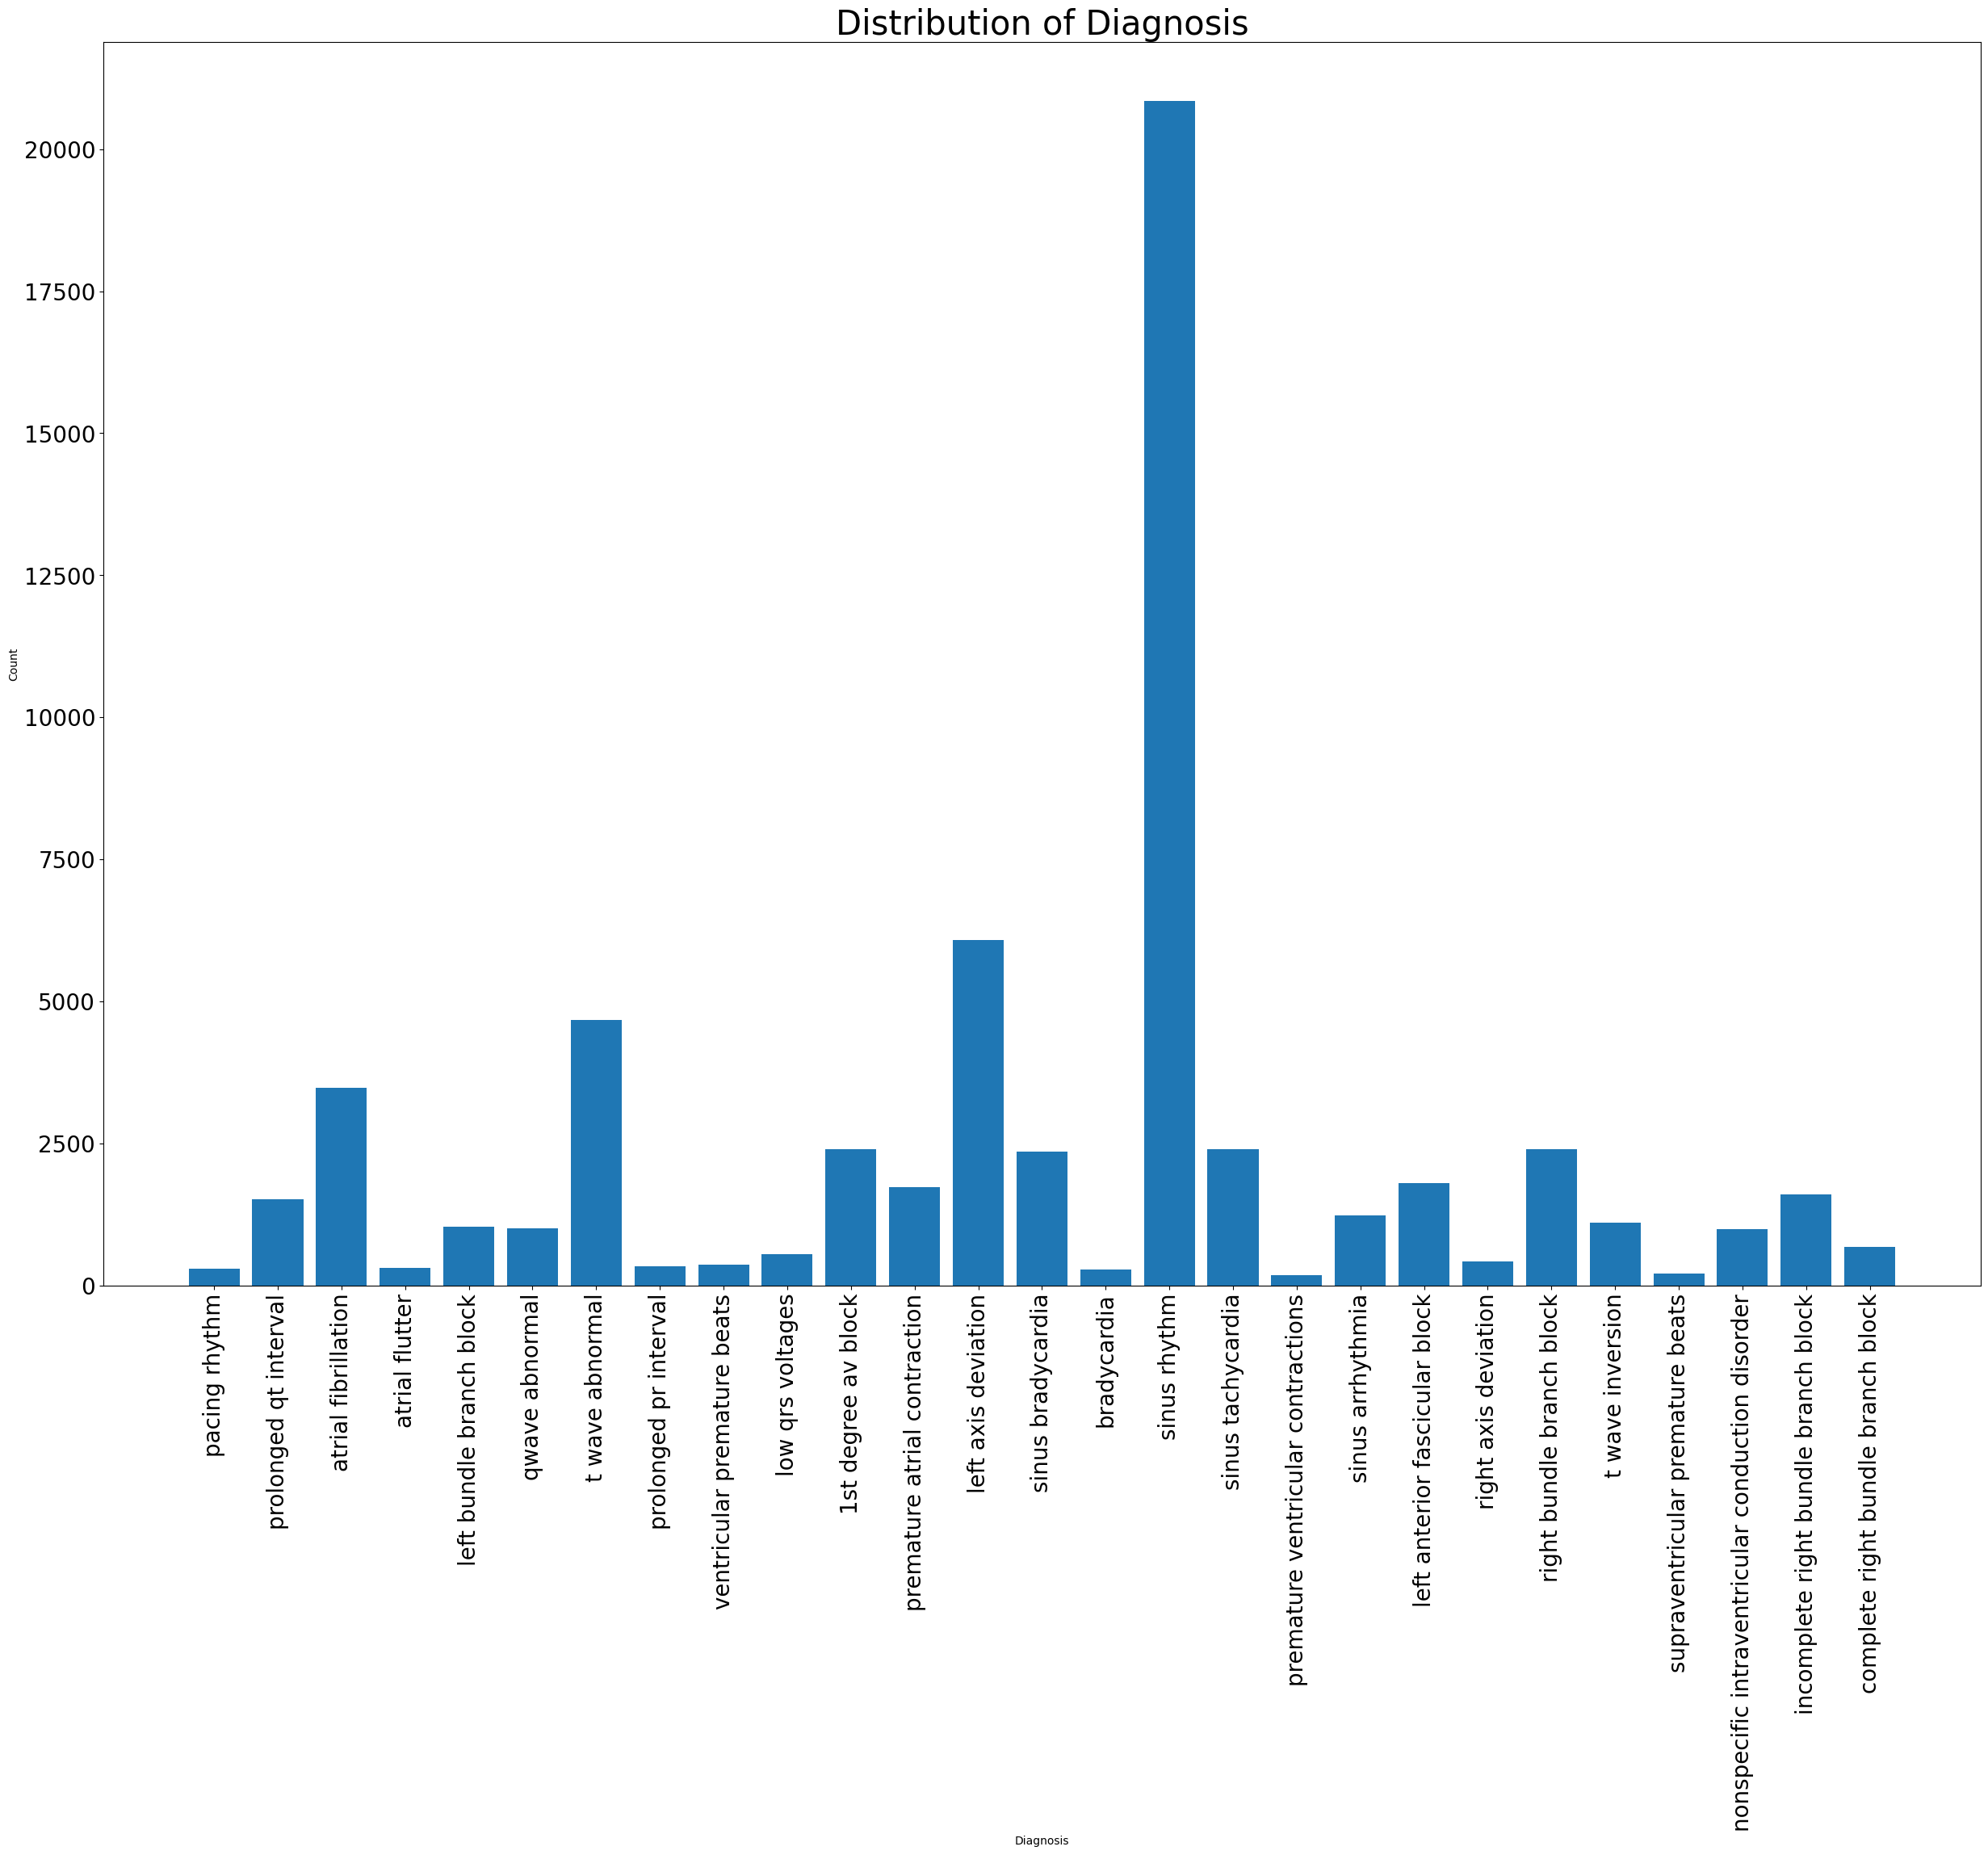

In [17]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [18]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [19]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


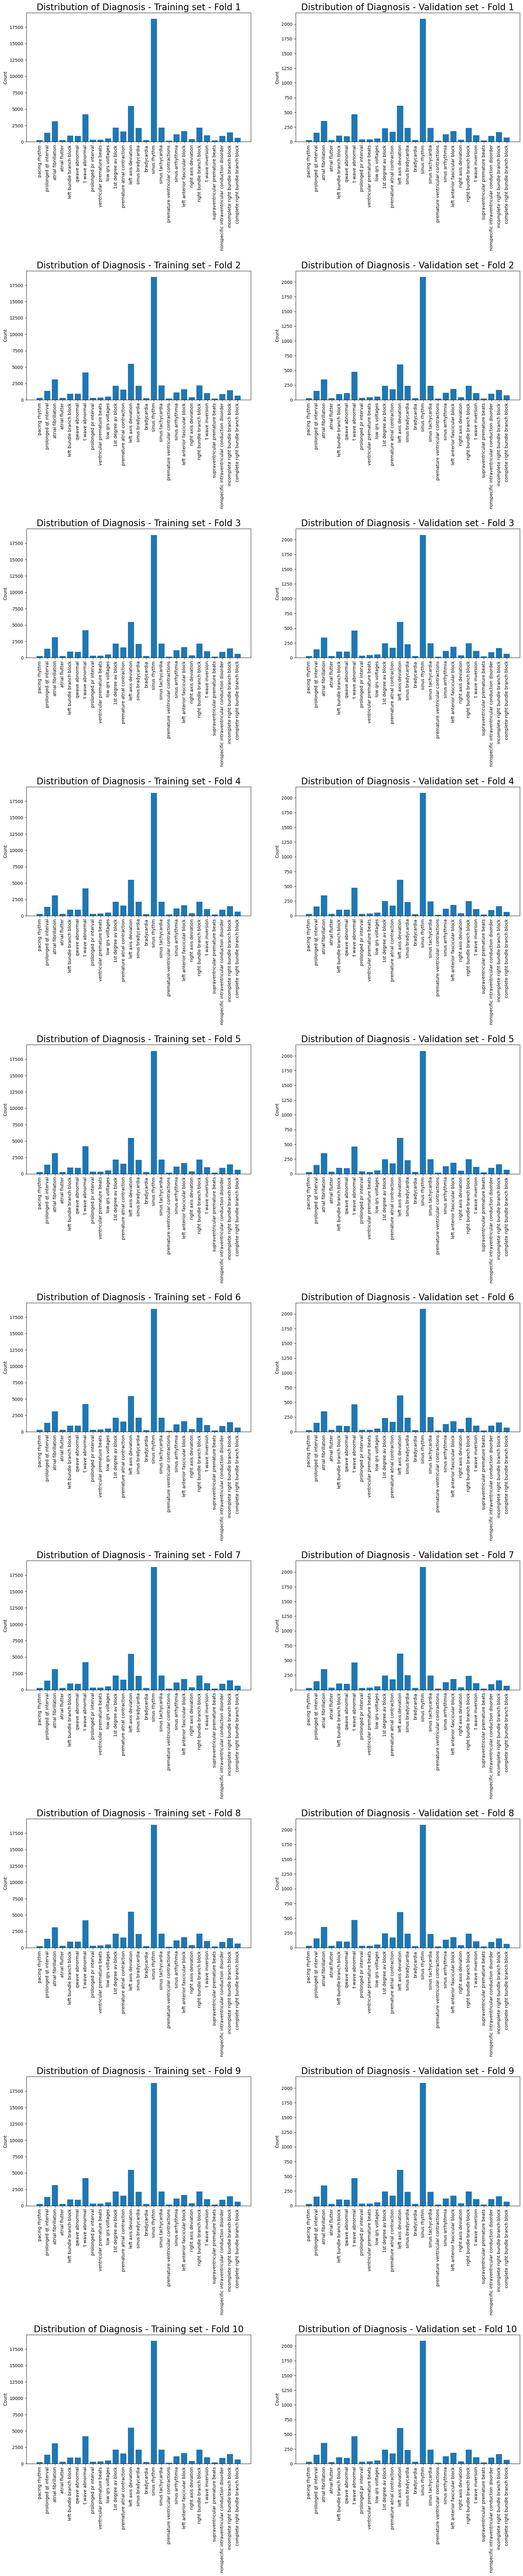

In [20]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [21]:
order_array = folds[0][0]

In [22]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled

def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [23]:
new_weights=pc.calculating_class_weights(y)

In [24]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [25]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [26]:
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [27]:
model = pc.residual_network_1d()

load a pre-trained model - trained parameters (weights & biases)

In [28]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

In [29]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 108s 794ms/step


In [30]:
init_thresholds = np.arange(0, 1, 0.05)

In [31]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y, folds[0][1])

0.1516625863156977
0.3257728585224567
0.34907885319229215
0.28868950738443655
0.181260365067383
0.07488523992867367
-0.030592151530913974
-0.13422631975369734
-0.2242114341113018
-0.3122581976641526
-0.3953465808086114
-0.47448587178946944
-0.5439621181557601
-0.6015332151710997
-0.6651141368699174
-0.7092221508645785
-0.7470735743049693
-0.7760926050516812
-0.8006819928304572
-0.8173020165059404


In [32]:
new_best_thr = optimize.fmin(thr_chall_metrics, 
                                args = (pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1], y_pred), 
                                x0 = init_thresholds[all_scores.argmax()] * np.ones(27))

Optimization terminated successfully.
         Current function value: -0.380630
         Iterations: 302
         Function evaluations: 579


In [33]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.38063028434382484


Make conf.matrix

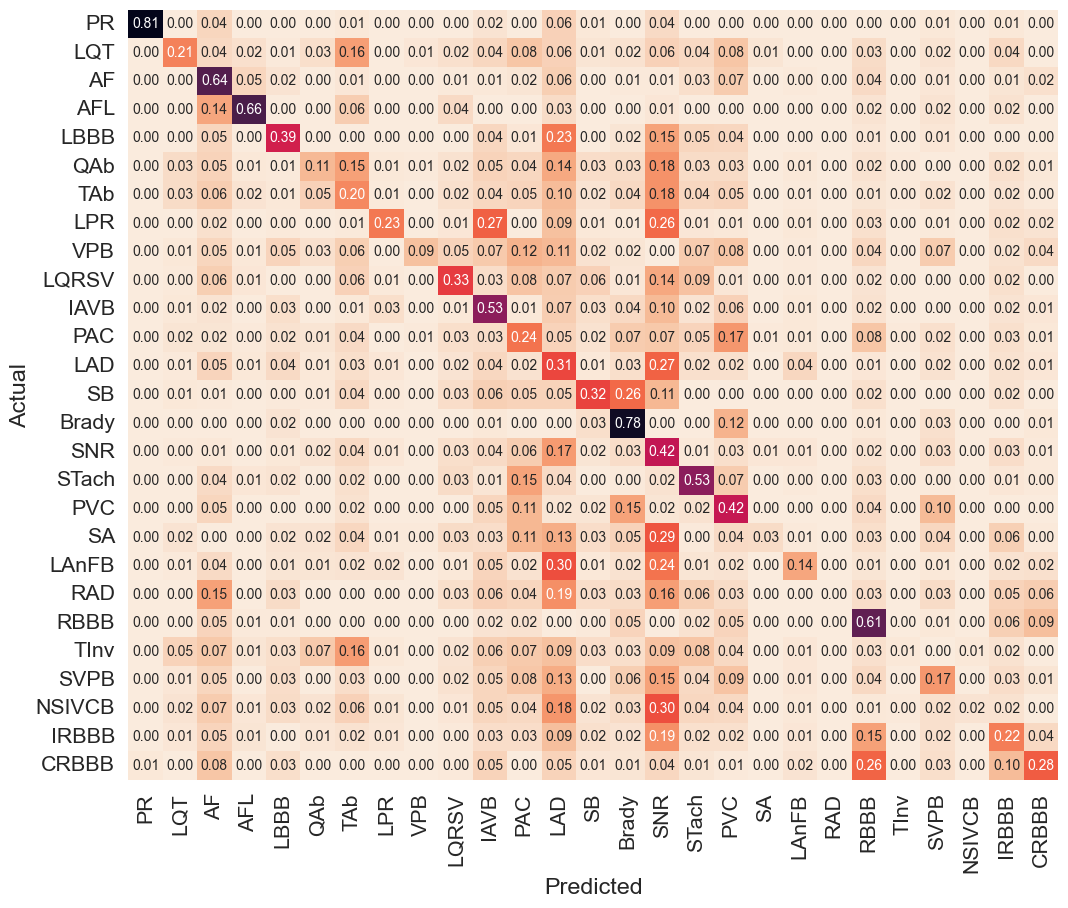

In [34]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [35]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


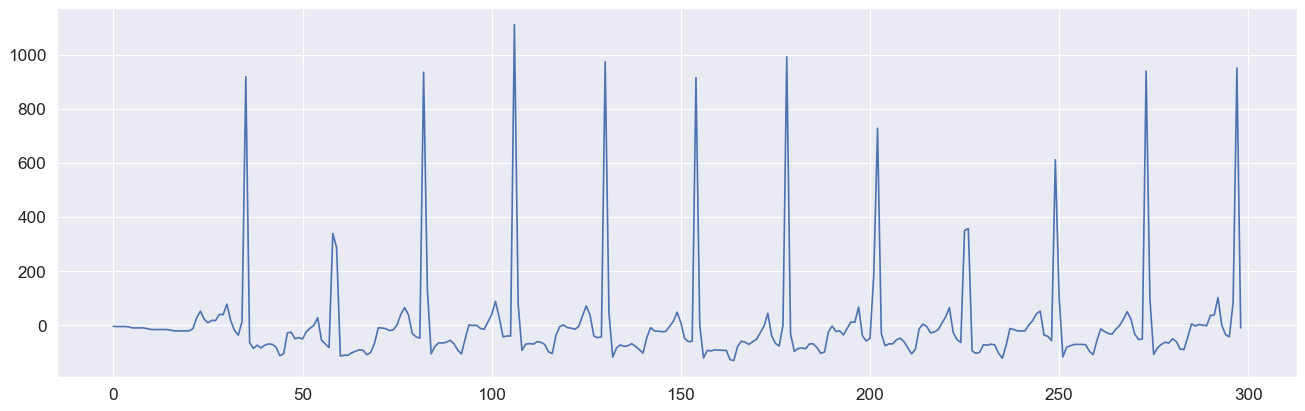

In [36]:
figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,1])

In [37]:
y_pred.shape

(4311, 27)

In [38]:
test_aa[:2,:,:].shape

(2, 5000, 12)

In [39]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

## TimeSHAP

### Local Events + Features

In [40]:
def ensure_3d(x):
    x = np.asarray(x)
    if x.ndim == 2:
        x = x[None, ...]
    assert x.ndim == 3, f"Expected 3D (B, T, F), got {x.shape}"
    return x

def predict_scores(x, model, target_idx=None, batch_size=128):
    x = ensure_3d(x).astype(np.float32)
    preds = model.predict(x, batch_size=batch_size, verbose=0)
    preds = np.asarray(preds)
    if preds.ndim == 1:
        return preds.reshape(-1, 1)
    if preds.ndim == 2:
        B, C = preds.shape
        if C == 1:
            return preds
        if target_idx is not None and 0 <= target_idx < C:
            return preds[:, target_idx:target_idx+1]
        if C == 2:
            return preds[:, 1:2]
        return np.take_along_axis(preds, np.argmax(preds, axis=1, keepdims=True), axis=1)
    return preds.reshape(preds.shape[0], -1)[:, :1]

TARGET_IDX = None  # set if your model is multi-class and you want a specific class
f = lambda x: predict_scores(x, model, target_idx=TARGET_IDX)

In [41]:
x_batch = ensure_3d(sample)                      # (10, 5000, 12)
x       = x_batch[0:1]                           # explain first sequence (1, 5000, 12)
baseline = x_batch.mean(axis=0, keepdims=True)   # (1, 5000, 12)

In [42]:
pruning_dict = {
    "tol": 0.15,   # pruning tolerance
    "w": 50,       # window size in steps
    "rs": 0,       # (optional) random seed
}

event_dict = {
    "nsamples": 200,
    "rs": 0,          # optional
}

feature_dict = {
    "nsamples": 200,  # <-- same here
    "rs": 0,          # optional
}

In [43]:
T_FULL = x_batch.shape[1]   # 5000
F_DIM  = x_batch.shape[2]   # 12

# pick the class of interest
# If you already have TARGET_IDX as an int, this will use it.
# Otherwise we'll auto-pick the most probable class on the baseline.
def _pick_target_idx(preds_on_baseline):
    if 'TARGET_IDX' in globals() and isinstance(TARGET_IDX, (int, np.integer)):
        return int(TARGET_IDX)
    # fallback: pick the class with highest baseline probability
    if preds_on_baseline.ndim == 1:
        return int(np.argmax(preds_on_baseline))
    return int(np.argmax(preds_on_baseline.mean(axis=0)))

# compute baseline prediction once to lock the index
_baseline_full = baseline.astype(np.float32, copy=False)
_baseline_preds = np.asarray(model.predict(_baseline_full, verbose=0))
if _baseline_preds.ndim == 1:
    _baseline_preds = _baseline_preds[:, None]
CLASS_IDX = _pick_target_idx(_baseline_preds)

def f_padded(xx):
    """
    Ensure the model always sees (B, 5000, 12) and we return (B, 1)
    for a single chosen class (CLASS_IDX).
    """
    xx = np.asarray(xx, dtype=np.float32, order="C")
    B, K, F = xx.shape
    assert F == F_DIM, f"Expected F={F_DIM}, got {F}"

    if K == T_FULL:
        x_full = xx
    else:
        pad_len = T_FULL - K
        # left-pad with baseline
        pad_block = np.broadcast_to(baseline[:, :pad_len, :], (B, pad_len, F_DIM))
        x_full = np.concatenate([pad_block, xx], axis=1)

    preds = np.asarray(model.predict(x_full, batch_size=128, verbose=0))
    if preds.ndim == 1:
        preds = preds[:, None]          # (B, 1)
    # select one class if multi-class
    if preds.shape[1] > 1:
        preds = preds[:, [CLASS_IDX]]   # (B, 1)
    return preds.astype(np.float32)


In [ ]:
# --- scorer that always returns (B,1) float32 ---
def f_safe(xx):
    xx = np.asarray(xx, dtype=np.float32, order="C")
    yy = predict_scores(xx, model, target_idx=TARGET_IDX)
    yy = np.asarray(yy, dtype=np.float32)
    return yy.reshape(-1, 1)

def local_explain(
    seq_id,
    *,
    FS=500,
    SECS=0.8,
    nsamples=300,
    x_batch=None,            # expect (N, T, F)
    baseline=None,           # can be None, scalar, (F,), (T,F), or (N,T,F)
    baseline_mode="zero"     # "zero" or "mean"
):
    """
    Local explanation for a single sequence using a fixed tail window.
    Returns: ev_i (events df), ft_i (features df), cell_df (or None), K
    """

    import numpy as np

    assert x_batch is not None, "x_batch must be provided (shape (N, T, F))"
    x_batch = np.asarray(x_batch, dtype=np.float32)
    assert x_batch.ndim == 3, f"x_batch must be (N,T,F); got {x_batch.shape}"
    N, T_total, F = x_batch.shape

    # 1) choose tail context length
    K = max(1, min(int(SECS * FS), T_total))
    xi        = x_batch[seq_id:seq_id+1]          # (1, T, F)
    xi_tail   = xi[:, -K:, :].astype(np.float32, copy=False)  # (1, K, F)

    # 2) build a baseline with shape (1, K, F)
    def make_base_tail(baseline, xi_tail, K, F):
        # Case A: no baseline provided
        if baseline is None:
            if baseline_mode == "mean":
                # feature-wise mean from the whole sample (safe fallback)
                mu = xi_tail.reshape(-1, F).mean(axis=0)          # (F,)
                return np.broadcast_to(mu.reshape(1, 1, F), xi_tail.shape).astype(np.float32)
            else:
                # zero baseline
                return np.zeros_like(xi_tail, dtype=np.float32)

        # Normalize user baseline to an array
        b = np.asarray(baseline, dtype=np.float32)

        # Case B: scalar -> broadcast to (1,K,F)
        if b.ndim == 0:
            return np.zeros_like(xi_tail, dtype=np.float32) + b

        # Case C: (F,) feature vector -> broadcast to (1,K,F)
        if b.ndim == 1 and b.shape[0] == F:
            return np.broadcast_to(b.reshape(1, 1, F), xi_tail.shape).astype(np.float32)

        # Case D: (K,F) or (T,F) -> take the last K rows, then add batch dim
        if b.ndim == 2 and b.shape[1] == F:
            if b.shape[0] >= K:
                return b[-K:, :][None, :, :].astype(np.float32)
            else:
                # pad at the front if shorter than K
                pad = np.zeros((K - b.shape[0], F), dtype=np.float32)
                return np.concatenate([pad, b], axis=0)[None, :, :]

        # Case E: (N,T,F) -> pick same seq_id, then slice last K
        if b.ndim == 3 and b.shape[2] == F:
            return b[seq_id:seq_id+1, -K:, :].astype(np.float32)

        raise ValueError(f"Unsupported baseline shape {b.shape}; expected scalar, (F,), (T,F), or (N,T,F).")

    base_tail = make_base_tail(baseline, xi_tail, K, F)  # (1, K, F)

    # 3) run TimeSHAP local (events & features)
    event_dict   = {"nsamples": nsamples, "rs": 0}
    feature_dict = {"nsamples": nsamples, "rs": 0}

    ev_i = local_event(f_safe, xi_tail, event_dict, seq_id, "entity_id", base_tail, 0)
    ft_i = local_feat (f_safe, xi_tail, feature_dict, seq_id, "entity_id", base_tail, 0)

    # 4) optional: cell-level per-time importances
    cell_df = None
    try:
        local_cell = getattr(tsx, "local_cell", None)
        if local_cell is not None:
            cell_df = local_cell(
                f_safe, xi_tail, {"nsamples": nsamples, "rs": 0},
                seq_id, "entity_id", base_tail, 0
            )
    except Exception:
        cell_df = None

    return ev_i, ft_i, cell_df, K


In [233]:
import numpy as np

def make_tail(x, fs=500, secs=0.8, seq_id=0):
    """
    Returns:
      xi_tail  : (1, K, F) last K steps of the selected sequence
      K        : int, number of timesteps in the tail window
      T, F     : ints, original sequence length and num features
    Accepts x as (T, F) or (N, T, F).
    """
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:         # (T, F) -> add batch dim
        x = x[None, ...]    # (1, T, F)
    assert x.ndim == 3, f"Expected (N,T,F) or (T,F); got {x.shape}"

    N, T, F = x.shape
    K = max(1, min(int(secs * fs), T))
    xi_tail = x[seq_id:seq_id+1, -K:, :]   # (1, K, F)
    return xi_tail, K, T, F


In [237]:
FS   = 500
SECS = 0.8
seq_id = 0

# If you already have a batch:
# x_batch: (N, T, F)
xi_tail, K, T, F = make_tail(x_batch, fs=FS, secs=SECS, seq_id=seq_id)

N, T, F = test_aa.shape
i = 0
ecg_sample = np.asarray(test_aa[i], dtype=np.float32)   # (5000, 12)

# If you only have a single ECG sample (T,12):
# ecg_sample: (T,12) or (12,T)
ecg_T12 = ecg_sample if ecg_sample.shape[1] == 12 else ecg_sample.T
xi_tail, K, T, F = make_tail(ecg_T12, fs=FS, secs=SECS, seq_id=0)  # becomes (1,K,12)


In [238]:
def make_baseline(xi_tail, mode="zero"):
    if mode == "zero":
        return np.zeros_like(xi_tail, dtype=np.float32)              # (1,K,F)
    if mode == "mean":
        mu = xi_tail.reshape(-1, xi_tail.shape[-1]).mean(axis=0)     # (F,)
        return np.broadcast_to(mu.reshape(1,1,-1), xi_tail.shape).astype(np.float32)
    raise ValueError("mode must be 'zero' or 'mean'")

base_tail = make_baseline(xi_tail, mode="zero")


In [220]:
ev_i, ft_i, cell_df, K = local_explain(
    seq_id=0, FS=500, SECS=0.8, nsamples=300,
    x_batch=x_batch,                 # (N,T,F)
    baseline=None,                   # or a scalar / (F,) / (T,F) / (N,T,F)
    baseline_mode="zero"             # or "mean"
)

In [257]:
from timeshap.explainer import local_event, local_feat, local_cell_level

# 1) make xi_tail and base_tail
xi_tail, K, *_ = make_tail(x_batch, fs=500, secs=0.8, seq_id=0)   # (1,K,F)
base_tail      = make_baseline(xi_tail, mode="zero")              # (1,K,F)

# 2) event/feature
event_dict   = {"nsamples": 300, "rs": 0}
feature_dict = {"nsamples": 300, "rs": 0}
ev_i = local_event(f_safe, xi_tail, event_dict,   0, "entity_id", base_tail, 0)
ft_i = local_feat (f_safe, xi_tail, feature_dict, 0, "entity_id", base_tail, 0)

# 3) cell-level (use ONE of the cell_dict variants above)
cell_dict = {
    "nsamples": 300,
    "rs": 0,
    "top_x_events": 10,
    "top_x_feats": 10
}

cell_df = local_cell_level(
    f_safe,       # scorer
    xi_tail,      # (1,K,F)
    cell_dict,    # includes selection rule
    ev_i,         # event df
    ft_i,         # feature df
    0,            # entity_uuid / seq_id
    "entity_id",  # entity column
    base_tail,    # (1,K,F)
    0             # pruned_idx
)


In [258]:
cell_df

,Event,Feature,Shapley Value
117,Other Events,Feature 8,0.305505
115,Other Events,Feature 6,0.213176
112,Other Events,Feature 2,0.171652
46,Event -129,Feature 7,0.095921
23,Event -316,Feature 4,0.085070
...,...,...,...
10,Event -318,Feature 0,-0.073214
97,Event -3,Feature 8,-0.075791
6,Event -362,Feature 7,-0.082604
31,Event -274,Feature 1,-0.093151


In [224]:
plot_event_heatmap(ev_i)

alt.LayerChart(...)

In [225]:
plot_feat_barplot(ft_i)

alt.LayerChart(...)

Top-K events (bar chart, local)

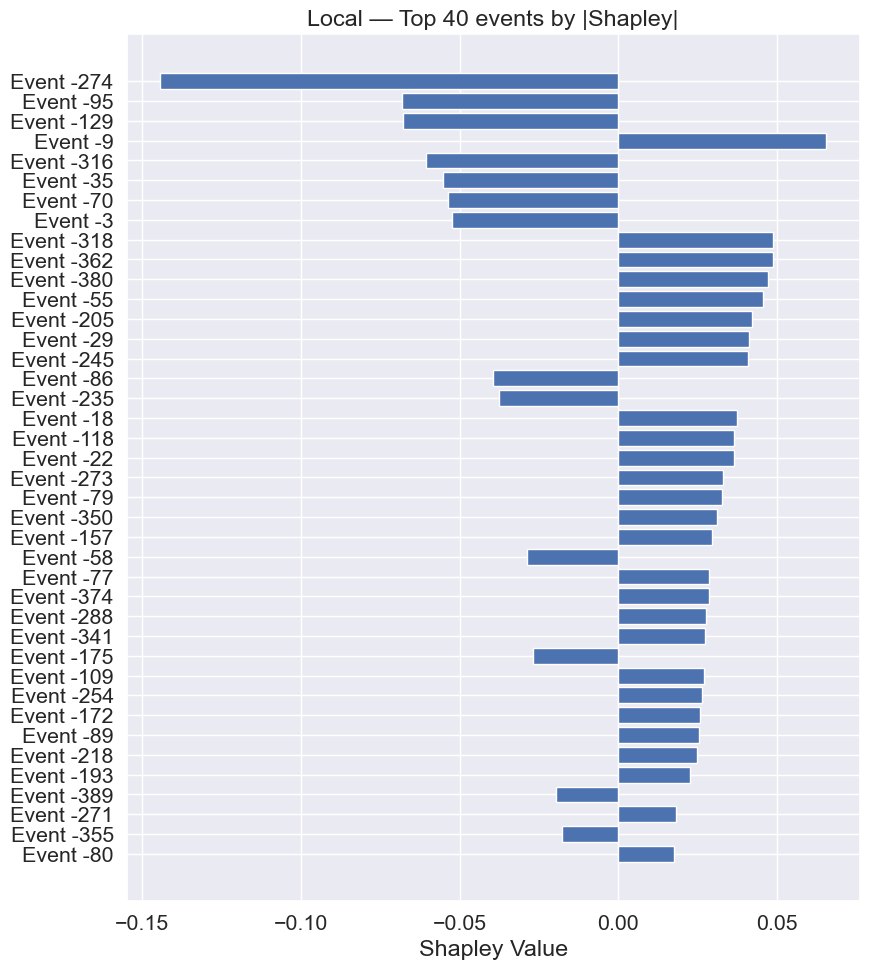

In [227]:
TOPK = 40
df = ev_i.copy()
df["abs"] = df["Shapley Value"].abs()
top_ev = df.nlargest(TOPK, "abs")

plt.figure(figsize=(9, 10))
plt.barh(top_ev["Feature"].astype(str), top_ev["Shapley Value"])
plt.gca().invert_yaxis()
plt.title(f"Local — Top {TOPK} events by |Shapley|")
plt.xlabel("Shapley Value")
plt.tight_layout(); plt.show()


In [228]:
TOPK = 40
df = ev_i.copy()
df["abs"] = df["Shapley Value"].abs()
top_ev = df.nlargest(TOPK, "abs").sort_values("abs")

fig = px.bar(
    top_ev,
    x="Shapley Value",
    y=top_ev["Feature"].astype(str),   # labels on y
    orientation="h",
    color="Shapley Value",             # diverging color by sign
    color_continuous_scale="RdBu",
    range_color=[-top_ev["abs"].max(), top_ev["abs"].max()],
    hover_data={"abs": True, "Shapley Value": True, "Feature": True},
    title=f"Local — Top {TOPK} events by |Shapley|",
)

fig.update_layout(yaxis_title="", xaxis_title="Shapley Value")
fig.add_vline(x=0, line_width=1, line_color="black")
fig.show()

Event Shapley as a line over time (local)

In [229]:
FS = 500  # sampling rate (Hz)

# Build time axis (seconds before prediction)
times = (np.arange(-K, 0) / FS).astype(float)

ev_line = ev_i.copy().reset_index(drop=True)
ev_line["time_s"] = times[:len(ev_line)]  # guard if lengths differ

fig = px.line(
    ev_line,
    x="time_s",
    y="Shapley Value",
    title="Local — Event Shapley over time",
    labels={"time_s": "Time (s) before prediction", "Shapley Value": "Shapley Value"},
)

# add zero reference line
fig.add_hline(y=0, line_width=1, line_color="black")

fig.update_layout(margin=dict(l=40, r=20, t=60, b=40))
fig.show()




Overlay one ECG lead with local event Shapley

In [230]:
seq_id = 0
lead0  = 0
FS     = 500

# time + data
t   = np.arange(-K, 0) / FS
Xi  = x_batch[seq_id:seq_id+1, -K:, :]           # (1, K, 12)
ecg_by_lead = [Xi[0, :, i] for i in range(Xi.shape[2])]

# shapley aligned
sh = ev_i["Shapley Value"].to_numpy()
if len(sh) < len(t):
    sh = np.pad(sh, (len(t)-len(sh), 0), mode="edge")
elif len(sh) > len(t):
    sh = sh[-len(t):]

# base fig
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=t, y=ecg_by_lead[lead0], name=f"Lead {lead0+1}",
               mode="lines", line=dict(width=1.5),
               hovertemplate="t=%{x:.3f}s<br>ECG=%{y:.4f}<extra></extra>"),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=t, y=sh, name="Shapley",
               mode="lines", line=dict(width=2),
               hovertemplate="t=%{x:.3f}s<br>Shapley=%{y:.5f}<extra></extra>"),
    secondary_y=True
)
fig.add_hline(y=0, line_width=1, line_color="black", secondary_y=True)

# dropdown buttons: update ECG trace (0), y-axis title, and the figure title
buttons = []
for i in range(len(ecg_by_lead)):
    buttons.append(dict(
        label=f"Lead {i+1}",
        method="update",
        args=[
            # (traces keep order): update y of trace0 and trace1, and trace0 name
            {"y": [ecg_by_lead[i], sh], "name": [f"Lead {i+1}", "Shapley"]},
            # update left y-axis title and figure title text
            {"yaxis": {"title": f"Lead {i+1} amplitude"},
             "title": {"text": f"Local — Lead {i+1} with Event Shapley (sequence {seq_id})"}}
        ],
    ))

fig.update_layout(
    # put dropdown top-left; increase top margin so nothing overlaps
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.005, xanchor="left",
        y=1.20,  yanchor="top",
        buttons=buttons,
        showactive=True,
        bgcolor="rgba(255,255,255,0.9)"
    )],
    title={"text": f"Local — Lead {lead0+1} with Event Shapley (sequence {seq_id})"},
    margin=dict(l=50, r=40, t=110, b=80),
    # legend below the chart so it never collides with the dropdown
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=-0.2, yanchor="top",
        bgcolor="rgba(255,255,255,0.6)",
        bordercolor="rgba(0,0,0,0.1)", borderwidth=1
    ),
    hovermode="x unified"
)
fig.update_xaxes(title_text="Time (s) before prediction", zeroline=False)
fig.update_yaxes(title_text=f"Lead {lead0+1} amplitude", secondary_y=False)
fig.update_yaxes(title_text="Shapley Value", secondary_y=True, zeroline=False)

fig.show()
# fig.write_html("local_overlay_dropdown_clean.html")


Local feature importance (already plotted, but here’s a custom Top-N)

In [231]:
TOPF = 12
fx = ft_i.copy()
fx["abs"] = fx["Shapley Value"].abs()
fx = fx.nlargest(TOPF, "abs").sort_values("abs")   # rank by |Shapley|, show signed bar

fig = px.bar(
    fx,
    x="Shapley Value",
    y=fx["Feature"].astype(str),
    orientation="h",
    color="Shapley Value",
    color_continuous_scale="RdBu",
    range_color=[-fx["abs"].max(), fx["abs"].max()],
    title=f"Local — Top {TOPF} features (leads) by |Shapley|",
    labels={"y": "", "x": "Shapley Value"},
    hover_data={"Feature": True, "Shapley Value":":.5f", "abs":":.5f"}
)
fig.add_vline(x=0, line_width=1, line_color="black")
fig.update_layout(margin=dict(l=40, r=20, t=60, b=40))
fig.show()



### Global Events + Features

In [53]:
# --- Build the long DataFrame (tail window) ---
K_TAIL = 200
sequence_id_feat = "entity_id"
time_feat        = "t"
model_features   = [f"lead_{i+1}" for i in range(x_batch.shape[2])]  # 12 names

X_tail = x_batch[:, -K_TAIL:, :]               # (N, K_TAIL, 12)
N, T, F = X_tail.shape

rows = []
for i in range(N):
    df_i = pd.DataFrame(X_tail[i], columns=model_features)  # feature columns by name
    df_i[sequence_id_feat] = i
    df_i[time_feat] = np.arange(T)                          # 0..T-1 within tail
    rows.append(df_i)

pos_dataset = pd.concat(rows, ignore_index=True)


In [54]:
# --- Baseline & dicts ---
average_event = X_tail.mean(axis=0, keepdims=True)  # (1, K_TAIL, 12)

pruning_dict = {"tol": 0.05, "w": 50, "rs": 0}
event_dict   = {"nsamples": 300, "rs": 0}
feature_dict = {"nsamples": 300, "rs": 0}

# --- IMPORTANT: schema must be a LIST (column order of the DataFrame) ---
schema = pos_dataset.columns.tolist()  # <-- list, not dict

# Sanity: ensure all model_features exist in schema
missing = [c for c in model_features if c not in schema]
assert not missing, f"These feature names aren't in the DataFrame: {missing}"

In [55]:
# gentler pruning
pruning_dict = {
    "tol": 1e-6,   # << very strict; prevents 'everything pruned'
    "w": 50,       # size of chunks to prune; keep <= K_TAIL
    "rs": 0
}

event_dict   = {"nsamples": 300, "rs": 0}
feature_dict = {"nsamples": 300, "rs": 0}

prun_stats, global_plot = global_report(
    f, 
    pos_dataset, 
    pruning_dict, 
    event_dict, 
    feature_dict,
    average_event, 
    model_features, 
    schema, 
    sequence_id_feat, 
    time_feat
)

display(global_plot)

No path to persist pruning data provided.
No random seed provided for event-level explanations. Using default: 42
No random seed provided for event-level explanations. Using default: 42
No path to persist event explanations provided.
No path to persist feature explanations provided.
Calculating pruning algorithm
Calculating event data
Calculating feat data
Calculating pruning indexes


alt.VConcatChart(...)

In [56]:
# Reuse the exact inputs you passed to global_report:
prun_indexes, event_df, feat_df = calc_global_explanations(
    f, pos_dataset, pruning_dict, event_dict, feature_dict,
    average_event, model_features, schema,
    sequence_id_feat, time_feat,
    append_to_files=False,  # don't write to disk
    max_instances=10,       # or len of your dataset
    verbose=False
)

No path to persist pruning data provided.
No path to persist event explanations provided.
No path to persist feature explanations provided.
Calculating pruning algorithm
Calculating event data
Calculating feat data


Global Top-K features (mean Shapley)

In [60]:
ft_plot = (feat_df
           .assign(abs=lambda d: d["Shapley Value"].abs())
           .groupby("Feature", as_index=False)
           .agg(MeanShap=("Shapley Value","mean"),
                AbsShap =("Shapley Value",lambda x: x.abs().mean()))
           .sort_values("AbsShap", ascending=False))

TOPF = 12
topf = ft_plot.head(TOPF).sort_values("MeanShap")  # sort for nice ascending bars

fig = px.bar(
    topf,
    x="MeanShap",
    y=topf["Feature"].astype(str),
    orientation="h",
    color="MeanShap",
    color_continuous_scale="RdBu",
    range_color=[-topf["MeanShap"].abs().max(), topf["MeanShap"].abs().max()],
    title=f"Global features — Top {TOPF} (mean Shapley)",
    labels={"x":"Mean Shapley Value", "y":""},
    hover_data={"Feature": True, "MeanShap":":.5f", "AbsShap":":.5f"}
)
fig.add_vline(x=0, line_width=1, line_color="black")
fig.update_layout(margin=dict(l=40, r=20, t=60, b=40))
fig.show()
# fig.write_html("global_top_features_mean.html")


In [61]:
print(event_df.columns.tolist())
print(event_df[["t (event index)","Shapley Value"]].describe())

print("Unique time indices:", event_df["t (event index)"].nunique())
print("Min/Max index:", event_df["t (event index)"].min(), event_df["t (event index)"].max())
print("Max |Shapley|:", event_df["Shapley Value"].abs().max())


['Random Seed', 'NSamples', 'Event', 'Shapley Value', 't (event index)', 'Entity', 'Tolerance']
       t (event index)  Shapley Value
count      2000.000000    2000.000000
mean        -99.500000       0.000617
std          57.748744       0.021246
min        -199.000000      -0.255438
25%        -149.250000       0.000000
50%         -99.500000       0.000000
75%         -49.750000       0.000000
max           0.000000       0.111132
Unique time indices: 200
Min/Max index: -199 0
Max |Shapley|: 0.25543807053215994


Global event curves (signed mean, and mean |Shapley|)

In [62]:
FS = 500  # ECG Hz
ev = event_df.copy()

idx = "t (event index)"           # already -K..0
ev = ev.dropna(subset=[idx]).copy()
ev[idx] = ev[idx].astype(int)
ev["time_s"] = ev[idx] / FS       # -K/FS .. 0 seconds

# a) signed mean ± std (can cancel to ~0)
agg_signed = (ev.groupby("time_s", as_index=False)
                .agg(mean=("Shapley Value","mean"),
                     std =("Shapley Value","std"))
                .sort_values("time_s"))

# b) mean |Shapley| (robust to cancellation)
agg_abs = (ev.groupby("time_s", as_index=False)
             .agg(mean_abs=("Shapley Value", lambda x: x.abs().mean()),
                  med_abs =("Shapley Value", lambda x: x.abs().median()))
             .sort_values("time_s"))

Signed mean ± std (shaded band)

In [63]:
# expects: agg_signed with columns ["time_s","mean","std"]
upper = agg_signed["mean"] + agg_signed["std"]
lower = agg_signed["mean"] - agg_signed["std"]

fig1 = go.Figure()

# std band (lower -> upper)
fig1.add_trace(go.Scatter(
    x=agg_signed["time_s"], y=lower,
    mode="lines", line=dict(width=0), showlegend=False,
    hoverinfo="skip"
))
fig1.add_trace(go.Scatter(
    x=agg_signed["time_s"], y=upper,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(31,119,180,0.15)", showlegend=False,
    hoverinfo="skip"
))

# mean line
fig1.add_trace(go.Scatter(
    x=agg_signed["time_s"], y=agg_signed["mean"],
    name="mean Shapley (signed)", mode="lines",
    hovertemplate="t=%{x:.3f}s<br>mean=%{y:.5f}<extra></extra>"
))

fig1.add_hline(y=0, line_width=1, line_color="black")

fig1.update_layout(
    title="Global event Shapley over time (signed mean ± std)",
    xaxis_title="Time (s) before prediction",
    yaxis_title="Shapley Value",
    hovermode="x unified",
    margin=dict(l=50, r=30, t=60, b=40),
)
fig1.show()


Mean |Shapley| & median |Shapley| (no cancellation)

In [64]:
# expects: agg_abs with columns ["time_s","mean_abs","med_abs"]
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=agg_abs["time_s"], y=agg_abs["mean_abs"],
    name="mean |Shapley|", mode="lines",
    hovertemplate="t=%{x:.3f}s<br>mean|φ|=%{y:.5f}<extra></extra>"
))
fig2.add_trace(go.Scatter(
    x=agg_abs["time_s"], y=agg_abs["med_abs"],
    name="median |Shapley|", mode="lines",
    hovertemplate="t=%{x:.3f}s<br>median|φ|=%{y:.5f}<extra></extra>"
))

fig2.update_layout(
    title="Global event importance over time",
    xaxis_title="Time (s) before prediction",
    yaxis_title="|Shapley|",
    hovermode="x unified",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.05, yanchor="bottom"),
    margin=dict(l=50, r=30, t=70, b=40),
)
fig2.show()


Top-K global events by |Shapley|

In [65]:
TOPK = 100
rank = (ev.groupby("time_s", as_index=False)
          .agg(mean_abs=("Shapley Value", lambda x: x.abs().mean()))
          .nlargest(TOPK, "mean_abs")
          .sort_values("time_s"))

x = rank["time_s"].to_numpy()
y = rank["mean_abs"].to_numpy()

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode="lines", line=dict(width=0), showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Top-K points",
                         hovertemplate="t=%{x:.3f}s<br>mean|φ|=%{y:.5f}<extra></extra>"))
fig.add_trace(go.Scatter(x=x, y=np.zeros_like(y), mode="lines",
                         line=dict(width=1), showlegend=False, hoverinfo="skip"))
# vertical stems: draw as shapes (fast)
for xi, yi in zip(x, y):
    fig.add_shape(type="line", x0=xi, x1=xi, y0=0, y1=yi)

fig.update_layout(
    title=f"Top {TOPK} global events by mean |Shapley|",
    xaxis_title="Time (s) before prediction",
    yaxis_title="mean |Shapley|",
    hovermode="x unified",
    margin=dict(l=50, r=30, t=60, b=40),
)
fig.show()



Stratify signed curves by prediction direction

In [66]:
# Build per-entity sign from model scores on the same tail window
def f_safe(x):
    y = predict_scores(x, model, target_idx=TARGET_IDX)
    return np.asarray(y, dtype=np.float32).reshape(-1,1)

# --- build per-entity sign using the tail window ---
N = X_tail.shape[0]
scores = f_safe(X_tail)[:, 0]
baseline_score = float(f_safe(average_event)[0, 0])

ent_map = pd.DataFrame({
    "Entity": np.arange(N),
    "sign": np.where(scores - baseline_score >= 0, "pos", "neg")
})

# ev must already have columns: ["Entity","time_s","Shapley Value"]
ev_s = ev.merge(ent_map, on="Entity", how="left")

agg_pos = (ev_s[ev_s["sign"] == "pos"]
           .groupby("time_s", as_index=False)
           .agg(mean=("Shapley Value", "mean"))
           .sort_values("time_s"))
agg_neg = (ev_s[ev_s["sign"] == "neg"]
           .groupby("time_s", as_index=False)
           .agg(mean=("Shapley Value", "mean"))
           .sort_values("time_s"))

# --- Plotly: two lines + zero reference, tidy legend ---
fig = go.Figure()

if not agg_pos.empty:
    fig.add_trace(go.Scatter(
        x=agg_pos["time_s"], y=agg_pos["mean"],
        mode="lines", name="pos",
        hovertemplate="t=%{x:.3f}s<br>mean=%{y:.5f}<extra></extra>"
    ))
if not agg_neg.empty:
    fig.add_trace(go.Scatter(
        x=agg_neg["time_s"], y=agg_neg["mean"],
        mode="lines", name="neg",
        hovertemplate="t=%{x:.3f}s<br>mean=%{y:.5f}<extra></extra>"
    ))

fig.add_hline(y=0, line_width=1, line_color="black")

fig.update_layout(
    title="Global event Shapley over time (stratified by prediction sign)",
    xaxis_title="Time (s) before prediction",
    yaxis_title="Shapley Value",
    hovermode="x unified",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.05, yanchor="bottom"),
    margin=dict(l=50, r=30, t=70, b=40),
)
fig.show()

Global features (leads) — plots

In [67]:
# ---- 0) Inputs you already have from your setup ----
feature_dict = {"nsamples": 300, "rs": 0}

# ---- 1) Get a features dataframe (feat_df): use existing or compute quickly ----
try:
    ft_df = feat_df.copy()  # if you already have it
except NameError:
    print("feat_df not found; building by looping local_feat over the tail window (no prune).")
    def f_safe(xx):
        yy = predict_scores(xx, model, target_idx=TARGET_IDX)
        return np.asarray(yy, dtype=np.float32).reshape(-1,1)

    rows_feat = []
    N = X_tail.shape[0]
    BASE = average_event.astype(np.float32, copy=False)
    for i in range(N):
        xi_tail = X_tail[i:i+1].astype(np.float32, copy=False)
        ft = local_feat(f_safe, xi_tail, feature_dict, i, "Entity", BASE, 0)
        ft["Entity"] = i
        rows_feat.append(ft)
    ft_df = pd.concat(rows_feat, ignore_index=True)

print("Feature columns:", ft_df.columns.tolist())

# ---- 2) Standardize column names we’ll use ----
# label column (which feature/lead); shapley value column
label_col = None
for c in ["Feature", "Lead", "Feature name", "Feature Name"]:
    if c in ft_df.columns: label_col = c; break
if label_col is None:
    raise KeyError(f"Couldn't find a feature label column in {list(ft_df.columns)}")

shap_col = None
for c in ["Shapley Value", "Shapley", "Contribution", "Value"]:
    if c in ft_df.columns: shap_col = c; break
if shap_col is None:
    raise KeyError(f"Couldn't find a Shapley column in {list(ft_df.columns)}")

# ---- 3) Aggregate globally ----
g_feat = (ft_df
          .assign(abs=lambda d: d[shap_col].abs())
          .groupby(label_col, as_index=False)
          .agg(MeanShap=(shap_col, "mean"),
               AbsShap =(shap_col, lambda x: x.abs().mean()),
               N=("Entity", "nunique") if "Entity" in ft_df.columns else (label_col, "size"))
          .sort_values("AbsShap", ascending=False))

Feature columns: ['Random Seed', 'NSamples', 'Feature', 'Shapley Value', 'Entity', 'Tolerance']


In [68]:
# Auto-detect label + shap columns (works with "Feature"/"Lead" etc.)
label_col = None
for c in ["Feature", "Lead", "Feature name", "Feature Name"]:
    if c in g_feat.columns: label_col = c; break
assert label_col is not None, f"Couldn't find feature label column in {list(g_feat.columns)}"


In [69]:
TOPF = min(12, len(g_feat))
top_abs = g_feat.head(TOPF).sort_values("AbsShap")  # ascending for nice bar order

fig_abs = px.bar(
    top_abs,
    x="AbsShap",
    y=top_abs[label_col].astype(str),
    orientation="h",
    title=f"Global features — Top {TOPF} by mean |Shapley|",
    labels={"AbsShap":"mean |Shapley|", label_col:""},
    hover_data={"AbsShap":":.5f", "MeanShap":":.5f", "N":True}
)
fig_abs.update_layout(margin=dict(l=60, r=20, t=60, b=40))
fig_abs.show()


Top features by signed mean Shapley (color shows direction)

In [70]:
top_signed = (g_feat
              .sort_values("MeanShap", key=lambda s: s.abs())
              .head(TOPF)
              .sort_values("MeanShap"))

rng = float(top_signed["MeanShap"].abs().max())

fig_signed = px.bar(
    top_signed,
    x="MeanShap",
    y=top_signed[label_col].astype(str),
    orientation="h",
    color="MeanShap",
    color_continuous_scale="RdBu",
    range_color=[-rng, rng],
    title=f"Global features — Top {TOPF} by |mean Shapley| (signed)",
    labels={"MeanShap":"mean Shapley", label_col:""},
    hover_data={"MeanShap":":.5f", "AbsShap":":.5f", "N":True}
)
fig_signed.add_vline(x=0, line_width=1, line_color="black")
fig_signed.update_layout(margin=dict(l=60, r=20, t=60, b=40))
fig_signed.show()
# fig_signed.write_html("global_top_features_signed.html")


Per-entity variability (for top features) – jittered scatter

In [71]:
if "Entity" in ft_df.columns:
    keep_feats = set(g_feat.head(min(8, TOPF))[label_col].tolist())
    jitter = ft_df[ft_df[label_col].isin(keep_feats)].copy()
    # small x-jitter per feature to reduce overlap
    feat_to_x = {f:i for i, f in enumerate(sorted(keep_feats))}
    jitter["x_pos"] = jitter[label_col].map(feat_to_x)
    jitter["x_jit"] = jitter["x_pos"] + np.random.normal(0, 0.06, size=len(jitter))

    val_col = next(c for c in ["Shapley Value","Shapley","Contribution","Value"] if c in jitter.columns)

    fig_var = px.scatter(
        jitter,
        x="x_jit", y=val_col,
        color=jitter[label_col].astype(str),
        labels={val_col:"Shapley Value"},
        title="Global features — per-entity Shapley (subset of top features)",
        opacity=0.55
    )
    fig_var.add_hline(y=0, line_width=1, line_color="black")
    fig_var.update_layout(
        showlegend=True,
        xaxis=dict(
            tickmode="array",
            tickvals=list(feat_to_x.values()),
            ticktext=[str(k) for k in feat_to_x.keys()],
            title=""
        ),
        margin=dict(l=60, r=20, t=70, b=60)
    )
    fig_var.show()
    # fig_var.write_html("global_features_variability.html")


A single figure with a toggle (Mean vs |Mean|)

In [72]:
base = g_feat.head(TOPF)
# Start on AbsShap (magnitude)
order_abs = base.sort_values("AbsShap")
order_mean= base.sort_values("MeanShap")

fig_toggle = go.Figure()

# AbsShap trace
fig_toggle.add_bar(
    x=order_abs["AbsShap"],
    y=order_abs[label_col].astype(str),
    orientation="h",
    name="mean |Shapley|",
    marker_color="steelblue"
)
# MeanShap trace (hidden initially)
fig_toggle.add_bar(
    x=order_mean["MeanShap"],
    y=order_mean[label_col].astype(str),
    orientation="h",
    name="mean Shapley (signed)",
    visible=False,
    marker_color="indianred"
)

fig_toggle.update_layout(
    title=f"Global features — Top {TOPF}",
    barmode="group",
    margin=dict(l=70, r=20, t=70, b=40),
    updatemenus=[dict(
        type="buttons", direction="right",
        x=0.5, xanchor="center", y=1.12, yanchor="top",
        buttons=[
            dict(label="mean |Shapley|",
                 method="update",
                 args=[{"visible":[True, False]},
                       {"xaxis":{"title":"mean |Shapley|"}, "legend":{"orientation":"h"}}]),
            dict(label="mean Shapley (signed)",
                 method="update",
                 args=[{"visible":[False, True]},
                       {"xaxis":{"title":"mean Shapley"}}]),
        ]
    )]
)
fig_toggle.update_yaxes(title="")
fig_toggle.show()
# fig_toggle.write_html("global_features_toggle.html")


## LIME implementation

LOCAL Interpretations

In [73]:
# 2) Build a robust model_predict wrapper (auto-handles [N,T,F] vs [N,F,T])
model_predict_TS = make_model_predict(model)

In [74]:
# 3) Pick an ECG sample
N, T, F = test_aa.shape
i = 0
ecg_sample = np.asarray(test_aa[i], dtype=np.float32)   # (5000, 12)

lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"][:F]

# Quick sanity: one forward pass on the original sample
_ = model_predict_TS(ecg_sample[None, ...])

In [75]:
# 4) Run LOCAL LIME
CLASS_INDEX = 1   # set to the class you want to explain (e.g., AFib)
res_local = lime_local(
    model_predict=model_predict_TS,
    x=ecg_sample,
    class_index=CLASS_INDEX,
    n_events=32,            # 16–64 typical
    n_feature_masks=300,    # start small for speed, then increase
    n_event_masks=400,      # start small for speed, then increase
    batch_size=256,         # bump to 512/1024 if you have memory
    removal="zero",         # or "mean"/"noise"
    event_mode="fixed"      # or "beats" with beats=... if you have R-peaks
)


In [206]:
res_local

{'feature_importance': array([ 0.01438038,  0.0008789 , -0.00035611,  0.00760636,  0.00402343,
         0.01833186, -0.00419842,  0.01016091, -0.00522812,  0.01987928,
         0.01110959,  0.01708075], dtype=float32),
 'event_importance': array([ 7.6491199e-04,  1.2957584e-03,  1.5128441e-03,  1.7750524e-03,
         1.5572198e-03,  1.8747188e-03,  4.2313710e-04,  1.3463199e-03,
         2.1133767e-03,  1.1788886e-03,  9.5374137e-04,  2.2535939e-03,
         7.4643083e-04,  1.3261773e-03,  7.8322738e-04,  1.4141658e-03,
         2.0044474e-03,  4.8656203e-04,  2.1105520e-03,  5.5076927e-04,
         2.9506907e-04,  1.4707204e-03,  1.4449749e-04,  1.1450853e-03,
        -2.9104203e-04,  7.6282769e-05,  1.9080192e-04,  7.2700530e-04,
         6.6585094e-04,  1.4290828e-03,  1.0076882e-03,  1.3770722e-03],
       dtype=float32),
 'cell_importance': array([[1.36256847e-03, 1.43555761e-03, 1.69150787e-03, 4.13198795e-05,
         7.83867785e-04, 2.18149554e-03, 2.48781056e-03, 4.88100224e-

In [76]:
# 5) Plot LOCAL results
plot_feature_importance_plotly(res_local["feature_importance"], feature_names=lead_names,
                                title="Local Feature Importance (LIME)")
plot_event_importance_plotly(res_local["event_importance"], res_local["event_slices"], sr=None,
                                title="Local Event Importance (LIME)")
plot_cell_heatmap_plotly(res_local["cell_importance"], feature_names=lead_names,
                            title="Local Cell Importance (Event×Feature, LIME)")
plot_signal_with_event_overlay_plotly(ecg_sample, res_local["event_importance"], res_local["event_slices"], sr=None,
                                        title="Overlay: ECG Lead1 + LIME Event Importance")

GLOBAL Interpretations

In [77]:
# 1) Compute & cache locals once
os.makedirs("lime_locals", exist_ok=True)

subset_idx = np.random.default_rng(0).choice(len(test_aa), size=24, replace=False)
for n in subset_idx:
    out = f"lime_locals/idx_{int(n)}.pkl"
    if os.path.exists(out): 
        continue
    res = lime_local(
        model_predict=model_predict_TS,
        x=test_aa[n].astype("float32"),
        class_index=CLASS_INDEX,
        n_events=32,
        n_feature_masks=120,
        n_event_masks=150,
        batch_size=512
    )
    with open(out, "wb") as f:
        pickle.dump(res, f)

# 2) Aggregate cached locals -> "global" (instant)
feat_list, event_list, cell_sum = [], [], None
for p in glob.glob("lime_locals/idx_*.pkl"):
    with open(p, "rb") as f: r = pickle.load(f)
    feat_list.append(r["feature_importance"])
    event_list.append(r["event_importance"])
    f_imp = np.abs(r["feature_importance"] - np.mean(r["feature_importance"]))
    e_imp = np.abs(r["event_importance"] - np.mean(r["event_importance"]))
    f_imp = f_imp / (f_imp.sum() + 1e-12)
    e_imp = e_imp / (e_imp.sum() + 1e-12)
    cell = np.outer(e_imp, f_imp)
    if cell_sum is None: cell_sum = np.zeros_like(cell)
    cell_sum += cell

feat_global  = np.vstack(feat_list).mean(axis=0)
event_global = np.vstack(event_list).mean(axis=0)
cell_global  = cell_sum / len(feat_list)


In [78]:
# use your plotting helpers
plot_feature_importance_plotly(feat_global, feature_names=lead_names, title="Global Feature Importance (LIME)")
plot_event_importance_plotly(event_global, r["event_slices"], title="Global Event Importance (LIME)")
plot_cell_heatmap_plotly(cell_global, feature_names=lead_names, title="Global Cell Importance (LIME)")

## LIME + TimeSHAP

Drop-in helpers: normalize, align, extract from your TimeSHAP DFs

In [79]:
# ---------- normalization ----------
def _nz_abs_norm(v):
    v = np.asarray(v, float)
    v = np.abs(v - v.mean())
    s = v.sum()
    return v / s if s > 0 else v

# ---------- align TimeSHAP events to LIME windows by overlap ----------
def align_events_by_overlap(lime_slices, src_scores, src_slices=None, T=None):
    """
    Map event scores defined on src_slices (or per-time scores) onto lime_slices by temporal overlap.
    Returns an array of length len(lime_slices).
    """
    lime_slices = np.asarray(lime_slices, int)
    if src_slices is None:
        if T is None:
            T = len(src_scores)
        src_slices = np.stack([np.arange(0, T-1), np.arange(1, T)], axis=1)
    else:
        src_slices = np.asarray(src_slices, int)

    src_scores = np.asarray(src_scores, float)
    E_l = len(lime_slices)
    out = np.zeros(E_l, float)

    len_src = (src_slices[:,1] - src_slices[:,0]).clip(min=1)
    for i, (ls, le) in enumerate(lime_slices):
        acc = 0.0
        for j, (ss, se) in enumerate(src_slices):
            ov = max(0, min(le, se) - max(ls, ss))
            if ov > 0:
                acc += (ov / len_src[j]) * src_scores[j]
        out[i] = acc
    return out

# ---------- robust extractors from your TimeSHAP outputs ----------
def extract_timeshap_event(ev_i, K):
    """
    ev_i: DataFrame returned by timeshap.local_event (your ev_i).
    Returns (scores[E], slices[E,2]) with integer [start,end) indices in the K-long tail.
    Tries common column names; falls back to uniform slicing if needed.
    """
    assert ev_i is not None and len(ev_i) > 0, "Empty TimeSHAP event dataframe"

    df = ev_i.copy()
    cols = {c.lower(): c for c in df.columns}

    # 1) importance / phi
    score_col = None
    for key in ["importance", "phi", "score", "value"]:
        if key in cols:
            score_col = cols[key]; break
    if score_col is None:
        # try first numeric column
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        score_col = num_cols[0]
    scores = df[score_col].to_numpy().astype(float)

    # 2) start/end columns (if present)
    s_col = None; e_col = None
    for key in ["start", "s", "t_start", "begin"]:
        if key in cols: s_col = cols[key]; break
    for key in ["end", "e", "t_end", "stop"]:
        if key in cols: e_col = cols[key]; break

    if s_col is not None and e_col is not None:
        starts = df[s_col].to_numpy().astype(int)
        ends   = df[e_col].to_numpy().astype(int)
        slices = np.stack([starts, ends], axis=1)
        # clamp to [0, K]
        slices[:,0] = np.clip(slices[:,0], 0, K)
        slices[:,1] = np.clip(slices[:,1], 0, K)
    else:
        # fallback: assume events are consecutive uniform chunks over the K tail
        E = len(scores)
        edges = np.linspace(0, K, E+1, dtype=int)
        slices = np.stack([edges[:-1], edges[1:]], axis=1)

    return scores, slices

def extract_timeshap_feature(ft_i, F_dim):
    """
    ft_i: DataFrame from timeshap.local_feat (your ft_i).
    Returns a vector length F_dim aligned to your 12 leads order.
    Tries to find 'feature'/'lead'/'channel' names; otherwise assumes ft_i is already in order.
    """
    assert ft_i is not None and len(ft_i) > 0, "Empty TimeSHAP feature dataframe"

    df = ft_i.copy()
    cols = {c.lower(): c for c in df.columns}

    # score column
    score_col = None
    for key in ["importance", "phi", "score", "value"]:
        if key in cols:
            score_col = cols[key]; break
    if score_col is None:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        score_col = num_cols[0]

    # id / name column
    id_col = None
    for key in ["feature", "lead", "channel", "name", "feat"]:
        if key in cols:
            id_col = cols[key]; break

    scores = np.zeros(F_dim, float)
    if id_col is not None:
        # try to map names like "V1","I",... to indices [0..F_dim-1]
        # If your ft_i already has numeric indices 0..F-1, this will just work.
        idx = df[id_col].to_numpy()
        vals = df[score_col].to_numpy().astype(float)
        # Try numeric first
        if np.issubdtype(idx.dtype, np.number):
            idx = idx.astype(int)
            ok = (idx >= 0) & (idx < F_dim)
            scores[idx[ok]] = vals[ok]
        else:
            # fallback: assume ft_i is already in correct order/top-F listing
            vals = vals[:F_dim]
            scores[:len(vals)] = vals
    else:
        # no id; assume listed in feature order
        vals = df[score_col].to_numpy().astype(float)[:F_dim]
        scores[:len(vals)] = vals

    return scores


Fuse LIME + TimeSHAP (local) & plot

In [80]:
# simple fusion choices
def fuse_vectors(v_lime, v_shap, alpha=0.5):
    a = _nz_abs_norm(v_lime); b = _nz_abs_norm(v_shap)
    return alpha*a + (1-alpha)*b

def fuse_cells(cell_lime, ev_shap, ft_shap, alpha=0.5):
    A = np.asarray(cell_lime, float); A = np.abs(A - A.mean()); A /= (A.sum() + 1e-12)
    B = np.outer(_nz_abs_norm(ev_shap), _nz_abs_norm(ft_shap))
    C = alpha*A + (1-alpha)*B
    return C / (C.sum() + 1e-12)

def combine_timeshap_lime_local(
    ecg_sample,                    # (T, F) for the SAME ECG used in TimeSHAP
    ev_i, ft_i, K,                 # from your local_explain(...)
    res_local_lime,                # result dict from lime_local(..., class_index=...)
    lead_names=None,
    alpha=0.5,                     # 0.5 = equal weight LIME/TimeSHAP
):
    # 1) LIME pieces
    lime_e_scores  = res_local_lime["event_importance"]     # [E_l]
    lime_f_scores  = res_local_lime["feature_importance"]   # [F]
    lime_cell      = res_local_lime["cell_importance"]      # [E_l, F]
    lime_slices    = res_local_lime["event_slices"]         # [E_l, 2]
    T, F_dim = ecg_sample.shape

    # 2) TimeSHAP pieces (extract robustly)
    ts_event_scores, ts_event_slices = extract_timeshap_event(ev_i, K=K)
    ts_feature_scores = extract_timeshap_feature(ft_i, F_dim=F_dim)

    # TimeSHAP was run on the tail K; LIME used the full T.
    # Align TS events (on K tail) to LIME windows (on full T):
    # Find where the K-tail starts (right-aligned tail):
    start_tail = T - K
    ts_event_slices_global = ts_event_slices + start_tail  # shift into [0..T)

    ts_e_aligned = align_events_by_overlap(
        lime_slices=lime_slices,
        src_scores=ts_event_scores,
        src_slices=ts_event_slices_global
    )

    # 3) Fuse vectors & cell
    fused_events   = fuse_vectors(lime_e_scores, ts_e_aligned, alpha=alpha)
    fused_features = fuse_vectors(lime_f_scores, ts_feature_scores, alpha=alpha)
    fused_cell     = fuse_cells(lime_cell, ts_e_aligned, fused_features, alpha=alpha)

    # 4) Plot (use your Plotly helpers)
    try:
        centers = np.array([0.5*(s+e) for s,e in lime_slices])
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=centers, y=_nz_abs_norm(lime_e_scores), name="LIME events"))
        fig.add_trace(go.Scatter(x=centers, y=_nz_abs_norm(ts_e_aligned), name="TimeSHAP events"))
        fig.add_trace(go.Scatter(x=centers, y=_nz_abs_norm(fused_events), name="Fused events", line=dict(dash="dash")))
        fig.update_layout(title="Event importance: LIME vs TimeSHAP vs Fused",
                          xaxis_title="Time (samples)", yaxis_title="Normalized importance")
        fig.show()
    except Exception:
        pass

    # Feature & cell plots (your Plotly funcs)
    try:
        plot_feature_importance_plotly(fused_features, feature_names=lead_names,
                                       title="Fused Feature Importance (Local)")
        plot_cell_heatmap_plotly(fused_cell, feature_names=lead_names,
                                 title="Fused Cell Importance (Local)")
    except Exception:
        pass

    # return fused + aligned pieces for further use
    return {
        "fused_events": fused_events,
        "fused_features": fused_features,
        "fused_cell": fused_cell,
        "ts_events_aligned": ts_e_aligned,
        "lime_events": lime_e_scores,
        "lime_features": lime_f_scores,
        "lime_cell": lime_cell,
        "lime_slices": lime_slices,
    }


In [81]:
# ecg_sample: (5000, 12)  for the same seq_id you passed to local_explain
# ev_i, ft_i, cell_df, K = local_explain(seq_id=0, FS=500, SECS=0.8, nsamples=300)
# res_local_lime = lime_local(..., x=ecg_sample, class_index=CLASS_IDX, ...)

lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
comb = combine_timeshap_lime_local(
    ecg_sample=ecg_sample,
    ev_i=ev_i, ft_i=ft_i, K=K,
    res_local_lime=res_local,
    lead_names=lead_names,
    alpha=0.5
)


Global fusion

In [82]:
def _nz_abs_norm(v):
    v = np.asarray(v, float)
    v = np.abs(v - v.mean())
    s = v.sum()
    return v / s if s > 0 else v

def fuse_vectors(v_lime, v_shap, alpha=0.5):
    a = _nz_abs_norm(v_lime); b = _nz_abs_norm(v_shap)
    return alpha*a + (1-alpha)*b

def align_events_by_overlap(lime_slices, src_scores, src_slices=None, T=None):
    """
    Map src event scores (on src_slices or per-time) onto lime_slices by overlap.
    Returns vector len(lime_slices).
    """
    lime_slices = np.asarray(lime_slices, int)
    if src_slices is None:
        if T is None: T = len(src_scores)
        src_slices = np.stack([np.arange(0, T-1), np.arange(1, T)], axis=1)
    else:
        src_slices = np.asarray(src_slices, int)

    src_scores = np.asarray(src_scores, float)
    out = np.zeros(len(lime_slices), float)
    len_src = (src_slices[:,1] - src_slices[:,0]).clip(min=1)
    for i, (ls, le) in enumerate(lime_slices):
        acc = 0.0
        for j, (ss, se) in enumerate(src_slices):
            ov = max(0, min(le, se) - max(ls, ss))
            if ov > 0:
                acc += (ov / len_src[j]) * src_scores[j]
        out[i] = acc
    return out

# ---- Extractors for TimeSHAP global outputs ----
def extract_timeshap_global_feature(feat_df, F_dim):
    """
    Returns a length-F_dim vector from TimeSHAP global feat_df.
    Tries common column names; if no ID column, takes top-F rows in order.
    """
    df = feat_df.copy()
    cols = {c.lower(): c for c in df.columns}

    # score column
    score_col = None
    for key in ["importance", "phi", "score", "value"]:
        if key in cols: score_col = cols[key]; break
    if score_col is None:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        score_col = num_cols[0]

    # id / name column (feature index or lead name)
    id_col = None
    for key in ["feature", "lead", "channel", "name", "feat", "feature_id"]:
        if key in cols: id_col = cols[key]; break

    scores = np.zeros(F_dim, float)
    if id_col is not None:
        idx = df[id_col].to_numpy()
        vals = df[score_col].to_numpy().astype(float)
        if np.issubdtype(idx.dtype, np.number):
            idx = idx.astype(int)
            ok = (idx >= 0) & (idx < F_dim)
            scores[idx[ok]] = vals[ok]
        else:
            # if names (e.g., "I","II","V1"...), map if you have lead_names; else fill in order
            vals = vals[:F_dim]
            scores[:len(vals)] = vals
    else:
        vals = df[score_col].to_numpy().astype(float)[:F_dim]
        scores[:len(vals)] = vals
    return scores

def extract_timeshap_global_event(event_df):
    """
    Returns (scores, slices) from TimeSHAP global event_df if available.
    If no start/end columns, returns (vector, None) assuming it is already per-event aligned.
    """
    df = event_df.copy()
    cols = {c.lower(): c for c in df.columns}

    score_col = None
    for key in ["importance", "phi", "score", "value"]:
        if key in cols: score_col = cols[key]; break
    if score_col is None:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        score_col = num_cols[0]

    s_col = None; e_col = None
    for key in ["start", "s", "t_start", "begin"]:
        if key in cols: s_col = cols[key]; break
    for key in ["end", "e", "t_end", "stop"]:
        if key in cols: e_col = cols[key]; break

    scores = df[score_col].to_numpy().astype(float)

    if s_col is not None and e_col is not None:
        starts = df[s_col].to_numpy().astype(int)
        ends   = df[e_col].to_numpy().astype(int)
        slices = np.stack([starts, ends], axis=1)
        return scores, slices
    else:
        # No explicit slices; treat as already aligned to the event index
        return scores, None


In [83]:
# Inputs you already have:
# feat_global  (LIME) : shape (F,)   e.g., F=12
# event_global (LIME) : shape (E,)   (E = #windows you used for LIME)
# event_df, feat_df   (TimeSHAP global outputs)
# lime_slices_global  : event window [E,2] used by LIME globals
#   -> if you didn't store it explicitly, reuse any representative LIME local run's slices:
#      lime_slices_global = res_local["event_slices"]

F_dim = len(feat_global)
shap_feat_global = extract_timeshap_global_feature(feat_df, F_dim=F_dim)

# Extract TimeSHAP event scores (+ slices if provided)
shap_event_scores_raw, shap_event_slices = extract_timeshap_global_event(event_df)

# If TS global has explicit [start,end) slices and they might differ from LIME's,
# align them to LIME's windows. Otherwise, assume already aligned by event index.
if shap_event_slices is not None:
    shap_event_global = align_events_by_overlap(
        lime_slices=res_local["event_slices"],
        src_scores=shap_event_scores_raw,
        src_slices=shap_event_slices
    )
else:
    # same number/order of windows assumed:
    shap_event_global = shap_event_scores_raw
    if len(shap_event_global) != len(event_global):
        # fall back: simple rescale to match length by linear interpolation over centers
        centers_l = np.array([0.5*(s+e) for s,e in res_local["event_slices"]], float)
        centers_s = np.linspace(centers_l.min(), centers_l.max(), num=len(shap_event_global))
        shap_event_global = np.interp(centers_l, centers_s, shap_event_global)

# --- Fuse (equal weights by default; adjust alpha if you trust one more) ---
fused_feat_global  = fuse_vectors(feat_global,  shap_feat_global,  alpha=0.5)
fused_event_global = fuse_vectors(event_global, shap_event_global, alpha=0.5)


In [84]:
plot_feature_importance_plotly(fused_feat_global, feature_names=lead_names,
                               title="Fused Feature Importance (Global)")
plot_event_importance_plotly(fused_event_global, res_local["event_slices"],
                             title="Fused Event Importance (Global)")


## Combined Overlays

Paints TimeSHAP as the smooth background heat-strip.

Draws LIME intervals as translucent bands on top.

Returns the Axes and (vmin, vmax) so you can add a colorbar.

In [113]:
xai_overlay_helpers_path = r"notebooks\finalproject\xai_overlay_helpers.py"
sys.path.append(os.path.dirname(xai_overlay_helpers_path))
from xai_overlay_helpers import overlay_lime_timeshap, importance_colorbar

In [168]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def _to_Tx12(ecg_sample):
    x = np.asarray(ecg_sample)
    if x.ndim != 2 or 12 not in x.shape:
        raise ValueError(f"Need (T,12) or (12,T), got {x.shape}")
    return x if x.shape[1] == 12 else x.T  # (T,12)

def _decimate_for_display(x, max_points=4000):
    """Stride-decimate to keep plots crisp without aliasing the look."""
    n = len(x)
    if n <= max_points: 
        return slice(None)
    step = int(np.ceil(n / max_points))
    return slice(0, n, step)

def plot_ecg_plotly_all(ecg_sample, fs=500, leads=None, duration_sec=3.0,
                        yrange=(-2000, 2000), title="12-lead ECG (wave)",
                        line_shape="linear", max_points=4000, line_width=1.5):
    data = _to_Tx12(ecg_sample)            # (T,12)
    T = data.shape[0]
    # shorter window so the wave is visible
    n = min(int(duration_sec * fs), T)
    data = data[:n]
    t = np.arange(data.shape[0]) / float(fs)

    # decimate just for drawing (keeps the visual wave intact)
    sl = _decimate_for_display(t, max_points=max_points)
    t_d = t[sl]; data_d = data[sl, :]

    lead_names = leads or ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    fig = make_subplots(rows=6, cols=2, shared_xaxes=True,
                        subplot_titles=lead_names, vertical_spacing=0.06, horizontal_spacing=0.06)

    for i, nm in enumerate(lead_names):
        r, c = (i // 2) + 1, (i % 2) + 1
        fig.add_trace(
            go.Scatter(
                x=t_d, y=data_d[:, i],
                mode="lines",
                line=dict(width=line_width, shape=line_shape),
                hovertemplate="t=%{x:.3f}s<br>y=%{y}<extra></extra>",
                name=nm
            ),
            row=r, col=c
        )
        if yrange is not None:
            fig.update_yaxes(range=list(yrange), row=r, col=c)

    fig.update_xaxes(title_text="time (s)", row=6, col=1)
    fig.update_xaxes(title_text="time (s)", row=6, col=2)
    fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=0.2)   # 0.2s major grid
    fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=500)   # 500 units

    fig.update_layout(template="plotly_white", height=900, width=1150,
                      showlegend=False, title=title, margin=dict(l=50, r=30, t=60, b=40))
    fig.show()

def plot_ecg_plotly_single(ecg_sample, lead_name="II", fs=500, duration_sec=3.0,
                           yrange=(-2000, 2000), title=None,
                           line_shape="linear", max_points=4000, line_width=1.8):
    data = _to_Tx12(ecg_sample)
    T = data.shape[0]
    n = min(int(duration_sec * fs), T)
    data = data[:n]
    t = np.arange(data.shape[0]) / float(fs)

    sl = _decimate_for_display(t, max_points=max_points)
    t_d = t[sl]

    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    idx = lead_names.index(lead_name)
    y_d = data[sl, idx]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=t_d, y=y_d, mode="lines",
        line=dict(width=line_width, shape=line_shape),
        hovertemplate="t=%{x:.3f}s<br>y=%{y}<extra></extra>"))
    if yrange is not None:
        fig.update_yaxes(range=list(yrange))
    fig.update_xaxes(title_text="time (s)", showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=0.2)
    fig.update_yaxes(title_text="ECG", showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=500)
    fig.update_layout(template="plotly_white", height=320, width=1000, showlegend=False,
                      title=title or f"ECG (Lead {lead_name}) — wave")
    fig.show()


In [169]:
# All 12, 3 seconds, ±2000, crisp wave
plot_ecg_plotly_all(ecg_sample, fs=500, duration_sec=3, yrange=(-2000, 2000))

# Single lead with a slightly bolder line
plot_ecg_plotly_single(ecg_sample, lead_name="V2", fs=500, duration_sec=3, yrange=(-2000, 2000))


In [202]:
# === Plotly ECG wave-format + TimeSHAP (bg) + LIME (bands) ===
import numpy as np
import plotly.graph_objects as go

# If these are already defined in your nb, this will reuse them; else we define them here.
try:
    _to_Tx12
except NameError:
    def _to_Tx12(ecg_sample):
        x = np.asarray(ecg_sample)
        if x.ndim != 2 or 12 not in x.shape:
            raise ValueError(f"Need (T,12) or (12,T), got {x.shape}")
        return x if x.shape[1] == 12 else x.T  # (T,12)

try:
    _decimate_for_display
except NameError:
    def _decimate_for_display(x, max_points=4000):
        n = len(x)
        if n <= max_points: 
            return slice(None)
        step = int(np.ceil(n / max_points))
        return slice(0, n, step)

def _select_timeshap_for_lead(ts, lead_idx):
    ts = np.asarray(ts)
    if ts.ndim == 1:       # (T,)
        return ts
    if ts.ndim == 2:       # (T,F) or (F,T)
        if ts.shape[1] == 12:   # (T,F)
            return ts[:, lead_idx]
        if ts.shape[0] == 12:   # (F,T)
            return ts[lead_idx, :]
        # Fallback: assume first dim is time, pick col 0
        return ts[:, 0] if ts.shape[0] >= ts.shape[1] else ts[0, :]
    raise ValueError(f"timeshap_values must be (T,) or (T,F); got {ts.shape}")

def _align_ts_to_wave(t_wave, ts_1d, fs, start_idx=None, end_idx=None):
    s = np.asarray(ts_1d).ravel()
    if (start_idx is not None) and (end_idx is not None) and len(s) == (end_idx - start_idx):
        out = np.zeros_like(t_wave, dtype=float)
        out[start_idx:end_idx] = s
        return out
    if len(s) == len(t_wave):
        return s
    # resample to wave grid
    t_src = np.arange(len(s)) / float(fs)
    return np.interp(t_wave, t_src, s, left=0.0, right=0.0)

def plot_ecg_timeshap_lime_wave(
    ecg_sample,
    timeshap_values,              # (T,) or (T,12)/(12,T)
    *,
    lead_name="II",
    fs=500,
    duration_sec=3.0,             # keep same default as your wave function
    yrange=(-2000, 2000),
    lime_intervals=None,          # list of (start_s, end_s, weight)
    res_local=None,               # optional dict with event_slices + event_importance
    start_idx=None, end_idx=None, # if SHAP was computed on a window
    max_points=4000,
    line_shape="linear",
    line_width=1.8,
    title=None
):
    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    lead_idx = lead_names.index(lead_name)

    # 1) Wave data (identical flow as your wave plot)
    data = _to_Tx12(ecg_sample)            # (T,12)
    T = data.shape[0]
    n = min(int(duration_sec * fs), T) if duration_sec is not None else T
    data = data[:n]
    t = np.arange(data.shape[0]) / float(fs)

    sl = _decimate_for_display(t, max_points=max_points)
    t_d = t[sl]
    y_d = data[sl, lead_idx]

    # 2) TimeSHAP for this lead → align to the same decimated time basis
    shap_1d = _select_timeshap_for_lead(timeshap_values, lead_idx)
    shap_full = _align_ts_to_wave(t, shap_1d, fs, start_idx, end_idx)
    shap_d = shap_full[sl]
    shap_d = np.nan_to_num(shap_d, nan=0.0, posinf=0.0, neginf=0.0)
    # gentle clip to keep color scale readable
    if np.isfinite(shap_d).any():
        lim = np.percentile(np.abs(shap_d), 99.0)
        lim = max(lim, 1e-9)
        shap_d = np.clip(shap_d, -lim, +lim)
    vmin, vmax = float(np.min(shap_d)), float(np.max(shap_d))
    if vmin == vmax:
        vmax = vmin + 1e-9

    # 3) LIME intervals (from dict if not given)
    if lime_intervals is None and isinstance(res_local, dict):
        if "event_slices" in res_local and "event_importance" in res_local:
            slices = np.asarray(res_local["event_slices"])
            weights = np.asarray(res_local["event_importance"]).ravel()
            lime_intervals = [(float(s)/fs, float(e)/fs, float(w)) for (s, e), w in zip(slices, weights)]
    lime_intervals = lime_intervals or []

    # 4) Compose figure — SAME “wave” look as your base
    fig = go.Figure()

    # TimeSHAP as thin heat strip across the y-range (background)
    z = np.vstack([shap_d, shap_d])  # 2 x N so Plotly renders a ribbon
    fig.add_trace(go.Heatmap(
        x=t_d, y=[yrange[0], yrange[1]], z=z,
        showscale=True, coloraxis="coloraxis",
        opacity=0.35, zmin=vmin, zmax=vmax, zmid=0.0,
        hoverinfo="skip"
    ))

    # ECG wave (line)
    fig.add_trace(go.Scatter(
        x=t_d, y=y_d, mode="lines",
        line=dict(width=line_width, shape=line_shape),
        name=f"Lead {lead_name}",
        hovertemplate="t=%{x:.3f}s<br>y=%{y}<extra></extra>"
    ))

    # LIME bands
    if lime_intervals:
        wmax = max(abs(w) for _,_,w in lime_intervals) or 1.0
        for (s, e, w) in lime_intervals:
            alpha = 0.18 + 0.32 * (abs(w) / wmax)
            fig.add_shape(
                type="rect",
                x0=s, x1=e, y0=yrange[0], y1=yrange[1],
                line=dict(width=0),
                fillcolor=f"rgba(220, 20, 60, {alpha})"
            )

    # Axes/grid — match your wave plot
    fig.update_xaxes(title_text="time (s)", showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=0.2)
    fig.update_yaxes(title_text="ECG", range=list(yrange), showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=500)

    fig.update_layout(
        coloraxis=dict(colorscale="RdBu", cmin=vmin, cmax=vmax, cmid=0.0, colorbar=dict(title="TimeSHAP")),
        template="plotly_white", height=360, width=1000, showlegend=False,
        title=title or f"ECG (Lead {lead_name}) + TimeSHAP + LIME"
    )
    fig.show()


In [203]:
# e.g., 3s window, ±2000, Lead V2
plot_ecg_timeshap_lime_wave(
    ecg_sample, timeshap_values,   # timeshap_values can be (T,) or (T,12)/(12,T)
    lead_name="aVF", fs=500,
    duration_sec=10.0,
    yrange=(-2000, 2000),
    lime_intervals=lime_intervals  # or res_local=...
)

plot_ecg_timeshap_lime_wave(
    ecg_sample, timeshap_values,   # timeshap_values can be (T,) or (T,12)/(12,T)
    lead_name="II", fs=500,
    duration_sec=10.0,
    yrange=(-2000, 2000),
    lime_intervals=lime_intervals  # or res_local=...
)

In [263]:
# ==== Continuous ECG wave (no decimation) + TimeSHAP (bg) + LIME (bands) ====
import numpy as np
import plotly.graph_objects as go

def _to_Tx12(x):
    x = np.asarray(x)
    assert x.ndim == 2 and 12 in x.shape, f"Need (T,12) or (12,T), got {x.shape}"
    return x if x.shape[1] == 12 else x.T

def _clip99(x):
    x = np.asarray(x, float)
    finite = np.isfinite(x)
    if not finite.any(): return x
    lim = np.percentile(np.abs(x[finite]), 99.0)
    return np.clip(x, -max(lim, 1e-9),  max(lim, 1e-9))

def _align_timeshap(timeshap_1d, n, fs):
    s = np.asarray(timeshap_1d, float).ravel()
    if len(s) == n:
        return s
    # resample to current window length
    t_src = np.arange(len(s)) / float(fs)
    t_dst = np.arange(n) / float(fs)
    return np.interp(t_dst, t_src, s, left=0.0, right=0.0)

def plot_ecg_timeshap_lime_continuous(
    ecg_sample,
    timeshap_1d,                 # (T,) per-time attribution (TimeSHAP/IG/etc.). If None, pass zeros.
    *,
    lead_name="II",
    fs=500,
    duration_sec=5.0,            # use 3–5 s for crisp spikes; or None for full record
    yrange=(-2000, 2000),
    lime_intervals=None,         # list of (start_s, end_s, weight)
    line_width=1.6,
    title=None
):
    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    lead_idx = lead_names.index(lead_name)

    # --- wave data (no decimation) ---
    data = _to_Tx12(ecg_sample)       # (T,12)
    T = data.shape[0]
    n = T if duration_sec is None else min(int(duration_sec * fs), T)
    data = data[:n]
    t = np.arange(n) / float(fs)
    y = data[:, lead_idx]

    # --- TimeSHAP bg (align length, clean, robust scale) ---
    if timeshap_1d is None:
        ts = np.zeros(n, dtype=float)
    else:
        ts_full = _align_timeshap(timeshap_1d, n, fs)
        ts = np.nan_to_num(ts_full, nan=0.0, posinf=0.0, neginf=0.0)
        ts = _clip99(ts)
    vmin, vmax = float(np.min(ts)), float(np.max(ts))
    if vmin == vmax: vmax = vmin + 1e-9

    # --- figure ---
    fig = go.Figure()

    # TimeSHAP ribbon (continuous along x, stretched across y-range)
    z = np.vstack([ts, ts])  # 2 x N so Heatmap renders a strip
    fig.add_trace(go.Heatmap(
        x=t, y=[yrange[0], yrange[1]], z=z,
        showscale=True, coloraxis="coloraxis",
        opacity=0.35, zmin=vmin, zmax=vmax, zmid=0.0,
        hoverinfo="skip"
    ))

    # ECG waveform (lines, no decimation)
    fig.add_trace(go.Scatter(
        x=t, y=y, mode="lines",
        line=dict(width=line_width, shape="linear"),  # keep "linear" for true ECG look
        name=f"Lead {lead_name}",
        hovertemplate="t=%{x:.3f}s<br>y=%{y}<extra></extra>"
    ))

    # LIME bands
    if lime_intervals:
        wmax = max(abs(w) for _,_,w in lime_intervals) or 1.0
        for (s, e, w) in lime_intervals:
            alpha = 0.18 + 0.32*(abs(w)/wmax)
            fig.add_shape(
                type="rect",
                x0=float(s), x1=float(e), y0=yrange[0], y1=yrange[1],
                line=dict(width=0),
                fillcolor=f"rgba(220,20,60,{alpha})"
            )

    # axes / layout
    fig.update_xaxes(title_text="time (s)", showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=0.2)
    fig.update_yaxes(title_text="ECG", range=list(yrange), showgrid=True, gridcolor="rgba(0,0,0,0.12)", dtick=500)
    fig.update_layout(
        coloraxis=dict(colorscale="RdBu", cmin=vmin, cmax=vmax, cmid=0.0, colorbar=dict(title="TimeSHAP")),
        template="plotly_white", height=360, width=1000, showlegend=False,
        title=title or f"ECG (Lead {lead_name}) — continuous wave + TimeSHAP + LIME"
    )
    fig.show()


In [266]:
# Example: 5 seconds, continuous, with your LIME intervals
# timeshap_1d_full : (T,), e.g. from cell_df or IG; or None/zeros
# lime_intervals   : from res_local → [(s/fs, e/fs, weight), ...]

plot_ecg_timeshap_lime_continuous(
    ecg_sample=ecg_sample,
    timeshap_1d=timeshap_1d_full,   # or np.zeros(_to_Tx12(ecg_sample).shape[0])
    lead_name=lead_name,             # e.g., "II"
    fs=fs,
    duration_sec=10.0,                # set None for full length (can be heavy)
    yrange=(-2000, 2000),
    lime_intervals=lime_intervals,
    line_width=1.8
)


## TELMI-style Class implementation

In [85]:
class Telmi:
    def __init__(self,model,data,num_perturbations: int,window_size:int, kernel_width=0.25):
        self.model = model
        self.data = data
        self.num_perturbations = num_perturbations
        self.window_size = window_size
        self.kernel_width = kernel_width
        self.num_features = data.shape[2]
        if len(data.shape) != 3:
            raise ValueError("input Data must be batch of instance")

    def _kernel_func(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / self.kernel_width ** 2))

    def _instance_feature_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,self.num_features)
        perturb_instance_predictions = np.array([model.predict(subset * instance) for subset in perturbations_sets])
        original_instance = np.ones(self.num_features)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_instance_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]
    
    def _instance_event_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        num_events = int(np.ceil(instance.shape[1] / self.window_size))
        events = list(self._create_event_chunks(instance[0].copy(),num_events))
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,num_events)
        perturb_events_predictions = []
        for subset in perturbations_sets:
            perturb_events = np.array(list(map(lambda x:x[0] * x[1], zip(events,subset))))
            perturb_events_predictions.append(model.predict(perturb_events))
        perturb_events_predictions = np.array(perturb_events_predictions)
        original_instance = np.ones(num_events)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_events_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]

    def feature_explain(self):
        return np.array(list(map(self._instance_feature_explain,self.data)))
    
    def event_explain(self):
        return np.array(list(map(self._instance_event_explain,self.data)))
    
    @staticmethod
    def _create_perturbations_sets(m: int, n: int):
        perturbations_sets = list(map(list, itertools.product([0, 1], repeat=n)))
        if m==-1 or m==2**n:
            return np.array(perturbations_sets)
        random_index = np.random.choice(len(perturbations_sets), m, replace=False)
        random_perturbations_sets = [perturbations_sets[i] for i in random_index]
        return np.array(random_perturbations_sets)

    @staticmethod
    def _create_event_chunks(instance, num_chunks: int):
        for i in range(0, len(instance), num_chunks):
            yield instance[i:i+num_chunks]   


In [86]:
x = Telmi(model,sample,200,500)

In [87]:
x.feature_explain()

1/1 [==============================] - 0s 57ms/step


array([[ 4.99265083e-02,  5.11110996e-02,  9.98443251e-02,
         6.82672889e-02,  6.70829985e-02, -2.37873333e-02,
        -1.30328279e-02,  2.02001596e-02,  1.08043028e-01,
         1.47094140e-02, -4.88103546e-02,  3.10049400e-02],
       [-3.32108022e-03,  9.87617815e-04, -8.75054339e-03,
         3.55615292e-03,  4.21222723e-03,  6.87710762e-03,
        -1.80953451e-03,  2.10176858e-03, -4.56808275e-03,
         6.68539966e-03,  9.60068443e-03, -3.00496725e-03],
       [-1.39953956e-03, -3.39426022e-03, -6.16809533e-03,
         1.35088224e-02,  2.50483596e-03,  1.65170942e-02,
         5.52729782e-03,  8.60815783e-03,  2.74860860e-03,
         1.55626991e-02,  5.15088105e-03,  8.53720241e-03],
       [-1.22643962e-04, -1.70082531e-04, -1.10832264e-03,
         7.30023771e-05, -2.48075648e-04,  1.11933384e-03,
        -1.02550530e-03,  1.10118172e-03, -1.07647676e-04,
         1.72071282e-03,  1.21698910e-03,  4.69618647e-05],
       [ 1.88790572e-02,  6.63132282e-02,  3.9221786

In [88]:
x.event_explain()

1/1 [==============================] - 0s 22ms/step


array([[-8.13917504e-05,  1.53244201e-21, -5.72791300e-23,
         6.91231472e-21,  1.34962420e-20,  1.23507063e-21,
        -1.12757784e-20, -1.02418119e-20, -1.55462301e-20,
        -5.55572794e-21],
       [-2.13852551e-01,  1.38409085e-16,  4.61631487e-17,
        -1.06650040e-16,  4.57223418e-17, -3.87220937e-17,
         1.13580029e-17, -3.49988005e-17,  6.80287442e-18,
         5.91232426e-17],
       [ 3.54288518e-03, -9.98464290e-19, -1.02723068e-18,
         3.39744303e-19, -1.62427805e-20, -6.42007643e-19,
         6.04832434e-19,  2.16969791e-19, -7.56399749e-19,
         6.82007441e-20],
       [ 7.75011750e-02, -4.12984788e-19, -3.59592693e-18,
        -6.49791716e-18, -2.14348718e-17,  9.58786083e-19,
        -1.58522325e-17, -1.75268013e-17, -1.07321269e-17,
         4.50600723e-17],
       [ 4.40487154e-02, -1.51614599e-17, -6.11965379e-18,
         2.60840978e-19, -4.54954475e-18,  6.88963322e-18,
         8.14180863e-18, -8.88919176e-18, -1.72336871e-17,
         1.

## Feature explain

In [89]:
sample_prediction = model.predict(sample)

1/1 [==============================] - 0s 258ms/step


In [90]:
top_classes = sample_prediction[0].argsort()

In [91]:
top_classes

array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [92]:
num_perturbations = 200
num_feature = 12
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[0, 0, 1, ..., 1, 1, 0],
       [1, 1, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 1, 1, 0],
       ...,
       [1, 1, 0, ..., 1, 0, 1],
       [0, 1, 0, ..., 0, 1, 1],
       [1, 1, 1, ..., 0, 0, 1]])

In [93]:
perturb_prediction = []
distance = []
for subset in perturbations:
    data = sample * subset
    perturb_prediction.append(model.predict(data))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 277ms/step


In [94]:
perturb_prediction.shape


(200, 10, 27)

In [95]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [96]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [97]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 0.00138993,  0.07670777,  0.06779003,  0.01966042,  0.04787341,
        0.04848161, -0.02857326, -0.00391019,  0.037795  ,  0.05766546,
       -0.01632849,  0.05328257])

In [98]:
Coeff_df = pd.DataFrame()

Coeff_df['TELMI'] = coeff

fig = px.bar(Coeff_df, x=Coeff_df['TELMI'], y= Coeff_df.index, orientation='h', color=Coeff_df.index)
fig.show()

In [99]:
fig = go.Figure(go.Waterfall(
    name = "20", 
    orientation = "h",
    x = Coeff_df['TELMI'],
    textposition = "outside",
    y = Coeff_df['TELMI'].index,    
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "TELMI Explanability",
        showlegend = True
)

fig.show()

## event explain

In [100]:
sample = np.array([test_aa[0]])

In [101]:
num_perturbations = 200
num_feature = 10
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[0, 1, 1, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [1, 1, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 1]])

In [102]:
reshaped_sample = sample.reshape((5000,12)).copy()

In [103]:
perturb_prediction = []
distance = []
for subset in perturbations:
    reshaped_sample = sample.reshape((5000,12)).copy()
    splited_event = np.array_split(reshaped_sample,10)
    for idx, value in enumerate(subset):
        if value == 0:
            splited_event[idx][:,:] = 0
    perturb_prediction.append(model.predict(np.array(splited_event)))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 53ms/step


In [104]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [105]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [106]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 1.63374348e-01,  2.14910165e-17, -9.07583740e-18,  5.48137632e-17,
       -4.47226698e-17, -5.36270979e-17, -3.08974579e-17, -1.03653477e-16,
        8.81739547e-17, -1.00356672e-16])